In [1]:
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import SpectralClustering
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import random
import copy
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)               
    np.random.seed(seed)          
    torch.manual_seed(seed)        
    torch.cuda.manual_seed(seed)    
    torch.cuda.manual_seed_all(seed)  
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False    

class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_dims=[100, 100], num_classes=10, 
                 dropout_p=0, activation='relu', init=True, init_method='kaiming'):
        super(MLP, self).__init__()
        self.hidden_dims = hidden_dims
        self.linear_layers = nn.ModuleList()
        layers = []

        # 1. 选择激活函数
        act_fn = self._get_activation(activation)
        
        # 构建网络结构
        current_dim = input_size
        for h_dim in hidden_dims:
            linear = nn.Linear(current_dim, h_dim)
            self.linear_layers.append(linear)
            layers.append(linear)
            layers.append(act_fn)
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            current_dim = h_dim
        
        # 输出层
        output_layer = nn.Linear(current_dim, num_classes)
        self.linear_layers.append(output_layer)
        layers.append(output_layer)
        
        self.network = nn.Sequential(*layers)
        
        # 2. 执行自定义初始化
        if init:
            self._initialize_weights(init_method)
        
    def _get_activation(self, name):
        name = name.lower()
        if name == 'relu': return nn.ReLU()
        elif name == 'tanh': return nn.Tanh()
        elif name == 'sigmoid': return nn.Sigmoid()
        elif name == 'leaky_relu': return nn.LeakyReLU()
        else: return nn.ReLU()

    def _initialize_weights(self, method):
        method = method.lower()
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if method == 'kaiming':
                    init.kaiming_normal_(m.weight, nonlinearity='relu')
                elif method == 'xavier':
                    init.xavier_normal_(m.weight)
                elif method == 'orthogonal':
                    init.orthogonal_(m.weight)
                elif method == 'normal':
                    init.normal_(m.weight, mean=0, std=0.01)
                
                if m.bias is not None:
                    init.constant_(m.bias, 0)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)
    
    def get_hidden_activations(self, x):
        """通用获取激活值方法，自动跳过 Dropout 和 Linear"""
        x = x.view(x.size(0), -1)
        activations = []
        for layer in self.network:
            x = layer(x)
            # 记录所有激活函数的输出
            if isinstance(layer, (nn.ReLU, nn.Tanh, nn.Sigmoid, nn.LeakyReLU)):
                activations.append(x.clone())
        return activations

    def get_adjacent_weights(self):
        """
        获取相邻隐藏层间的权重矩阵
        返回: 权重矩阵列表，每个元素是形状为[out_features, in_features]的张量
        """
        weight_matrices = []
        # 跳过输入层和输出层，只获取隐藏层之间的权重
        for i in range(1, len(self.linear_layers) - 1):
            # 获取第i-1层到第i层的权重（隐藏层之间）
            weight = self.linear_layers[i].weight.data.clone()  # shape: [out_features, in_features]
            weight_matrices.append(weight)
        return weight_matrices

def load_fashion_mnist(batch_size=128):
    """Load Fashion-MNIST dataset"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,))
    ])
    
    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=True, transform=transform, download=True
    )
    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=False, transform=transform, download=True
    )
    # batch_size = int(len(train_dataset)/10)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

def load_mnist(batch_size=128):

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = torchvision.datasets.MNIST(
        root='./data', train=True, transform=transform, download=True
    )
    test_dataset = torchvision.datasets.MNIST(
        root='./data', train=False, transform=transform, download=True
    )
    # batch_size = int(len(train_dataset)/2)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

def load_cifar10(batch_size=128):
    """Load CIFAR-10 dataset"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    
    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, transform=transform, download=True
    )
    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, transform=transform, download=True
    )
    # batch_size = int(len(train_dataset)/10)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

def train_model(model, train_loader, test_loader, epochs=5, learning_rate=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    # optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    
    # 存储容器
    train_losses = []        # 每 10 个 batch 记录一次
    train_accuracies = []    # 每 10 个 batch 记录一次
    test_accuracies = []     # 每个 epoch 记录一次
    model_states = []        # 每个 batch 都记录
    # state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    # model_states.append(state)
    
    print(f"训练开始 | 设备: {device} | 模式: 每 batch 保存权重，每 10 batch 计算指标")

    for epoch in range(epochs):
        model.train()
        
        for batch_idx, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)
            
            # 标准训练步骤
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            # --- [优化点 1] 每个 batch 必须保存权重 ---
            # 仅克隆参数字典到 CPU，不涉及计算，速度较快
            state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            model_states.append(state)

            # --- [优化点 2] 每 10 个 batch 计算一次 Loss 和 Acc ---
            if (batch_idx + 1) % 1 == 0:
                train_losses.append(loss.item())
                _, predicted = outputs.max(1)
                acc = 100. * predicted.eq(targets).sum().item() / targets.size(0)
                train_accuracies.append(acc)

            # 进度打印
            if (batch_idx + 1) % 200 == 0:
                print(f'Epoch: {epoch+1}/{epochs} | Batch: {batch_idx+1} | Loss: {loss.item():.4f}')

        # --- [优化点 3] 测试集评估（每个 Epoch 仅一次） ---
        model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for data, targets in test_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data)
                _, predicted = outputs.max(1)
                test_total += targets.size(0)
                test_correct += predicted.eq(targets).sum().item()
        
        epoch_test_acc = 100. * test_correct / test_total
        test_accuracies.append(epoch_test_acc)
        print(f'>> Epoch {epoch+1} 结束 | 测试准确率: {epoch_test_acc:.2f}%')
        
    return train_losses, train_accuracies, test_accuracies, model_states

def plot_training_curves(train_losses, train_accuracies, test_accuracies=None, 
                         vertical_line_at=None, save_path='training_curves.png'):
    """Plot training loss and accuracy curves
    
    Args:
        train_losses: list of training losses
        train_accuracies: list of training accuracies
        test_accuracies: optional list of test accuracies
        vertical_line_at: 单个数值 (如 100) 或数值列表 (如 [100, 200, 300]) 用于绘制竖线
        save_path: path to save figure (currently commented out)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs = range(1, len(train_losses) + 1)
    
    # 统一处理 vertical_line_at 为列表格式
    v_lines = []
    if vertical_line_at is not None:
        if isinstance(vertical_line_at, (int, float)):
            v_lines = [vertical_line_at]
        elif isinstance(vertical_line_at, (list, tuple)):
            v_lines = vertical_line_at
    
    # Plot training loss
    ax1.plot(epochs, train_losses, 'tab:red', linewidth=2, label='Training Loss')
    
    # 循环绘制多条竖线
    for v_line in v_lines:
        ax1.axvline(x=v_line, color='black', linestyle='--', linewidth=2, label=f'Step {v_line}')
        
    ax1.set_title('Training Loss Over Time', fontsize=14)
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss')
    # ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Plot accuracies
    ax2.plot(epochs, train_accuracies, 'tab:purple', linewidth=2, label='Training Accuracy')
    if test_accuracies is not None:
        ax2.plot(epochs, test_accuracies, 'r-', linewidth=2, label='Test Accuracy')
        
    # 循环绘制多条竖线
    for v_line in v_lines:
        ax2.axvline(x=v_line, color='black', linestyle='--', linewidth=2, label=f'Step {v_line}')
        
    ax2.set_title('Training and Test Accuracy Over Time', fontsize=14)
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Accuracy (%)')
    # ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def get_functional_connectivity(model, data_loader, samples_per_class=1000):
    """
    Get Original, Global, and Residual functional connectivity matrices 
    from neuron activations using PCA to decompose the major mode (PC1).
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()
    
    class_samples = {i: [] for i in range(10)}
    
    with torch.no_grad():
        for data, targets in data_loader:
            data, targets = data.to(device), targets.to(device)
            
            for i in range(len(targets)):
                class_label = targets[i].item()
                if len(class_samples[class_label]) < samples_per_class:
                    class_samples[class_label].append(data[i])
            
            if all(len(samples) >= samples_per_class for samples in class_samples.values()):
                break
    
    all_samples = []
    for class_label in range(10):
        all_samples.extend(class_samples[class_label][:samples_per_class])
    
    all_samples = torch.stack(all_samples).to(device)
    
    all_activations = []
    batch_size = 256
    
    with torch.no_grad():
        for i in range(0, len(all_samples), batch_size):
            batch = all_samples[i:i+batch_size]
            activations = model.get_hidden_activations(batch) 
            
            batch_concat = torch.cat(activations, dim=1)
            all_activations.append(batch_concat)
    
    Activation_Matrix = torch.cat(all_activations, dim=0).cpu().numpy()    

    # scaler = StandardScaler()
    # # Scaled_Activation_Matrix: N_samples x N_neurons
    # Scaled_Activation_Matrix = scaler.fit_transform(Activation_Matrix)
    
    FC_Original = np.corrcoef(Activation_Matrix.T)
    FC_Original = np.nan_to_num(FC_Original)
    
    return FC_Original


def train(act='tanh', init=True, init_method='orthogonal'):
    # Configuration
    set_seed(0) 
     
    # Create model
    model = MLP(input_size=input_size, hidden_dims=hidden_dims, activation=act, init=init, init_method=init_method)
    print(f"Model architecture: {model}")

    # Train model
    # print("Training model...")
    train_losses, train_accuracies, test_accuracies, models = train_model(
        model, train_loader, test_loader, epochs=epochs, learning_rate=learning_rate
    )
    return train_losses, train_accuracies, test_accuracies, models

from tqdm import tqdm
def analyze_connectivity_evolution(models, act = 'tanh', init_method = 'orthogonal', step_interval=10):    
    template_model = MLP(input_size=input_size, hidden_dims=hidden_dims)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    template_model.to(device)
    # 1. 重新定义容器（仅存储采样点的数据）
    sampled_steps = []
    scc_max_values = []
    fc_max_values = []
    fc_mean_abs_values = []
    is_mean_abs_values = []
    corr_values = []
    fc = []
    scc = []
    stats = {
        'prop_gt_095': [], 'prop_gt_09': [], 'prop_gt_08': [], 'prop_gt_07': [], 'prop_gt_075': [], 'prop_gt_06': [], 'prop_gt_05': [],
        'is_prop_gt_095': [], 'is_prop_gt_09': [], 'is_prop_gt_08': [], 'is_prop_gt_07': [], 'is_prop_gt_075': [], 'is_prop_gt_06': [], 'is_prop_gt_05': []
    }

    print("正在提取指标并对齐数据...")

    for i in tqdm(range(0, len(models), step_interval)):
        # 复用之前分析逻辑中的数据
        template_model.load_state_dict(models[i])
        template_model.eval()
        
        with torch.no_grad():
            # ---  is ---
            # weights = template_model.get_adjacent_weights()[0].cpu().numpy()
            weights = template_model.linear_layers[1].weight.detach().cpu().numpy()
            current_is = np.corrcoef(weights)
            is_triu = current_is[np.triu_indices(100, k=1)]
            
            # --- 功能连接性 FC ---
            # FC_noise = get_functional_connectivity_random_noise(template_model, device=device)
            FC = get_functional_connectivity(template_model,train_loader, samples_per_class=100)

            fc_all_triu = FC[np.triu_indices(100, k=1)]
            fc_all_triu = np.abs(fc_all_triu)  # 取绝对值
            # 记录高相关性比例 (大于 0.9 和大于 0.8 的占比)
            total_pairs = len(fc_all_triu)
            stats['prop_gt_095'].append(np.sum(fc_all_triu > 0.95) / total_pairs * 100)
            stats['prop_gt_09'].append(np.sum(fc_all_triu > 0.9) / total_pairs * 100) # 转换为百分比
            stats['prop_gt_08'].append(np.sum(fc_all_triu > 0.8) / total_pairs * 100)
            stats['prop_gt_07'].append(np.sum(fc_all_triu > 0.7) / total_pairs * 100)
            stats['prop_gt_075'].append(np.sum(fc_all_triu > 0.75) / total_pairs * 100)
            stats['prop_gt_06'].append(np.sum(fc_all_triu > 0.6) / total_pairs * 100)
            stats['prop_gt_05'].append(np.sum(fc_all_triu > 0.5) / total_pairs * 100)

            stats['is_prop_gt_095'].append(np.sum(is_triu > 0.95) / total_pairs * 100)
            stats['is_prop_gt_09'].append(np.sum(is_triu > 0.9) / total_pairs * 100) # 转换为百分比
            stats['is_prop_gt_08'].append(np.sum(is_triu > 0.8) / total_pairs * 100)
            stats['is_prop_gt_07'].append(np.sum(is_triu > 0.7) / total_pairs * 100)
            stats['is_prop_gt_075'].append(np.sum(is_triu > 0.75) / total_pairs * 100)
            stats['is_prop_gt_06'].append(np.sum(is_triu > 0.6) / total_pairs * 100)
            stats['is_prop_gt_05'].append(np.sum(is_triu > 0.5) / total_pairs * 100)
            
            # --- 记录数据 ---
            # 假设关注的是第二层隐藏层的 FC [100:200, 100:200]
            fc_sub = FC[100:200, 100:200]
            # fc_sub = FC[0:100, 0:100] # 关注第一层隐藏层的 FC
            fc_triu = fc_sub[np.triu_indices(100, k=1)]
            sampled_steps.append(i)
            scc_max_values.append(np.max(is_triu))
            fc_max_values.append(np.max(fc_triu))
            is_mean_abs_values.append(np.mean(np.abs(is_triu)))
            fc_mean_abs_values.append(np.mean(np.abs(fc_triu)))
            # 计算相关性
            if np.any(is_triu) and np.any(fc_triu):
                c = np.corrcoef(is_triu, fc_triu)[0, 1]
                corr_values.append(np.nan_to_num(c))
            else:
                corr_values.append(0)

    # 2. 绘图（确保所有线共用 sampled_steps 作为 X 轴）
    plt.figure(figsize=(8, 5))

    plt.plot(sampled_steps, scc_max_values, label='Input similarity(IS)', linewidth=2)
    plt.plot(sampled_steps, fc_max_values, label='Functional connectivity(FC)', linewidth=2)
    plt.plot(sampled_steps, corr_values, label='IS-FC Pearson Corr', linewidth=2)
    # plt.plot(sampled_steps, stats['prop_gt_06'], label='Proportion of FC pairs > 0.6', linewidth=2)

    plt.xlabel('Training Steps', fontsize=12, fontweight='bold')
    plt.ylabel('Pearson Correlation', fontsize=12, fontweight='bold')
    # plt.title(f'(Activation: {act}, Init: {init_method})')
    # plt.title('FC-IS Pearson Correlation', fontsize=14, fontweight='bold')
    plt.title('FC-IS dynamic evolution', fontsize=14, fontweight='bold')
    plt.legend(prop={'weight': 'bold', 'size': 12})
    # plt.grid(True, alpha=0.3)
    plt.show()
    return sampled_steps, scc_max_values, fc_max_values, corr_values, stats, fc_mean_abs_values, is_mean_abs_values

Building MLP with hidden dimensions: [100, 100]
Model architecture: MLP(
  (linear_layers): ModuleList(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): Linear(in_features=100, out_features=100, bias=True)
    (2): Linear(in_features=100, out_features=10, bias=True)
  )
  (network): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)
训练开始 | 设备: cuda | 模式: 每 batch 保存权重，每 10 batch 计算指标
Epoch: 1/5 | Batch: 200 | Loss: 2.1988
>> Epoch 1 结束 | 测试准确率: 40.69%
Epoch: 2/5 | Batch: 200 | Loss: 0.6354
>> Epoch 2 结束 | 测试准确率: 85.46%
Epoch: 3/5 | Batch: 200 | Loss: 0.4178
>> Epoch 3 结束 | 测试准确率: 88.69%
Epoch: 4/5 | Batch: 200 | Loss: 0.3692
>> Epoch 4 结束 | 测试准确率: 91.40%
Epoch: 5/5 | Batch: 200 | Loss: 0.1783
>> Epoch 5 结束 | 测试准确率: 92.29%
正在提取指标并对齐数据...


100%|██████████| 1175/1175 [04:05<00:00,  4.78it/s]


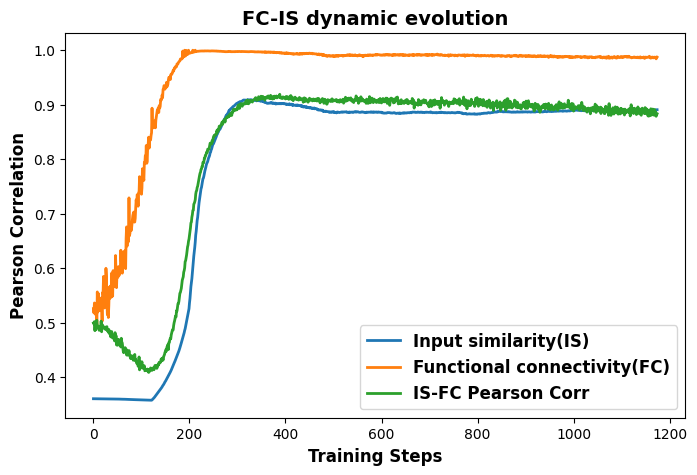

In [2]:
act = 'relu'
init_method = 'normal'
set_seed(0) 
hidden_dims = [100, 100]  # You can change this to [256, 128] or any other configuration
# dropout_p = 0.3
epochs = 5
batch_size = 256
learning_rate = 0.05 # 0.0001 for Adam
data = 'MNIST'    # MNIST or FashionMNIST or cifar10

print(f"Building MLP with hidden dimensions: {hidden_dims}")

# Load data
input_size=784
if data == 'FashionMNIST':
    train_loader, test_loader = load_fashion_mnist(batch_size=batch_size)
elif data == 'MNIST':
    train_loader, test_loader = load_mnist(batch_size=batch_size)
elif data == 'cifar10':
    train_loader, test_loader = load_cifar10(batch_size=batch_size)
    input_size=3072

train_losses, train_accuracies, test_accuracies, models = train(act=act, init=True, init_method=init_method)
sampled_steps, scc_max_values, fc_max_values, corr_values, fc_is_proportion, fc_mean_abs_values, is_mean_abs_values = analyze_connectivity_evolution(models, act=act, init_method=init_method, step_interval=1)

In [ ]:
# torch.save(models[-1], '../Supplementary_fig_code/checkpoints/mlp_final.pt')

### 1. Extracting cross-layer FC-SC-IS

In [134]:
import torch
import numpy as np

def calculate_multiplex_networks(model, data_loader, num_fc_samples=1000, num_jacob_samples=128):
    """
    计算两个隐藏层（共200个神经元）的 FC, SC, IS 矩阵。
    - L1 索引: 0~99
    - L2 索引: 100~199
    """
    device = next(model.parameters()).device
    model.eval()
    
    # 获取隐藏层权重
    # linear_layers[0]: Input -> L1 (100x784)
    # linear_layers[1]: L1 -> L2 (100x100)
    W1 = model.linear_layers[0].weight.detach().cpu().numpy()
    W2 = model.linear_layers[1].weight.detach().cpu().numpy()
    
    # ==========================================
    # 1. 结构连接矩阵 (Structural Connectivity, SC)
    # ==========================================
    SC_matrix = np.zeros((200, 200))
    # W2 的 shape 是 [100(L2), 100(L1)]。即 W2[i, j] 是从 L1 的 j 指向 L2 的 i 的权重
    # 将其放置在跨层区块中，并做成对称矩阵以便后续对比
    SC_matrix[100:200, 0:100] = W2
    SC_matrix[0:100, 100:200] = W2.T
    
    # ==========================================
    # 2. 功能连接矩阵 (Functional Connectivity, FC)
    # ==========================================
    all_acts_L1 = []
    all_acts_L2 = []
    collected_samples = 0
    set_seed(42) 
    
    with torch.no_grad():
        for data, _ in data_loader:
            data = data.to(device)
            if collected_samples >= num_fc_samples:
                break
                
            # 截取需要的样本数
            batch_size = data.size(0)
            if collected_samples + batch_size > num_fc_samples:
                data = data[:num_fc_samples - collected_samples]
                
            activations = model.get_hidden_activations(data)
            all_acts_L1.append(activations[0].cpu()) # L1 激活
            all_acts_L2.append(activations[1].cpu()) # L2 激活
            
            collected_samples += data.size(0)
            
    # 拼接所有批次的激活值并计算 FC [Samples, 200]
    acts_L1 = torch.cat(all_acts_L1, dim=0).numpy()
    acts_L2 = torch.cat(all_acts_L2, dim=0).numpy()
    acts_combined = np.concatenate([acts_L1, acts_L2], axis=1)
    
    FC_matrix = np.corrcoef(acts_combined.T)
    FC_matrix = np.nan_to_num(FC_matrix)
    
    # ==========================================
    # 3. 输入相似性矩阵 (Input Similarity, IS)
    # ==========================================
    IS_matrix = np.zeros((200, 200))
    
    # (a) 同层计算：直接使用权重矩阵的皮尔逊相关性
    IS_matrix[0:100, 0:100] = np.corrcoef(W1)
    IS_matrix[100:200, 100:200] = np.corrcoef(W2)
    
    # (b) 跨层计算：雅可比矩阵法 (Jacobian)
    # 取一个 Batch 用于计算梯度感受野
    model.train() # 确保开启梯度，部分层在 eval 下可能阻断反向传播
    data_iter = iter(data_loader)
    jacob_data, _ = next(data_iter)
    jacob_data = jacob_data[:num_jacob_samples].to(device)
    jacob_data.requires_grad_(True)
    
    # 前向传播
    jacob_acts = model.get_hidden_activations(jacob_data)
    act_L1 = jacob_acts[0]
    act_L2 = jacob_acts[1]
    
    # 存储梯度的容器 [100, 784]
    input_dim = jacob_data.view(jacob_data.size(0), -1).size(1)
    G_L1 = torch.zeros((100, input_dim))
    G_L2 = torch.zeros((100, input_dim))
    
    # 循环对 L1 的每个神经元求输入梯度
    for i in range(100):
        # 聚合该神经元在整个 Batch 上的激活求和，对其求导
        grad_l1 = torch.autograd.grad(outputs=act_L1[:, i].sum(), inputs=jacob_data, retain_graph=True)[0]
        # 取绝对值并在 Batch 维度平均，得到该神经元的稳定输入敏感度向量
        G_L1[i] = grad_l1.mean(dim=0).view(-1).cpu()
        
    # 循环对 L2 的每个神经元求输入梯度
    for i in range(100):
        grad_l2 = torch.autograd.grad(outputs=act_L2[:, i].sum(), inputs=jacob_data, retain_graph=True)[0]
        G_L2[i] = grad_l2.mean(dim=0).view(-1).cpu()
        
    # 释放梯度图
    del jacob_acts, act_L1, act_L2, grad_l1, grad_l2
    jacob_data.requires_grad_(False)
    torch.cuda.empty_cache()
    
    # 计算跨层 IS：将 L1 和 L2 的雅可比向量拼接后求相关性
    G_combined = torch.cat([G_L1, G_L2], dim=0).numpy()
    Jacobian_corr = np.corrcoef(G_combined)
    Jacobian_corr = np.nan_to_num(Jacobian_corr)
    
    # 将雅可比相关性矩阵的非对角区块（跨层部分）填入 IS_matrix
    IS_matrix[0:100, 100:200] = Jacobian_corr[0:100, 100:200]
    IS_matrix[100:200, 0:100] = Jacobian_corr[100:200, 0:100]
    
    # 确保对角线自相关为 1
    np.fill_diagonal(IS_matrix, 1.0)
    np.fill_diagonal(SC_matrix, 0.0) # SC 自身没有连接
    np.fill_diagonal(FC_matrix, 1.0)
    
    return FC_matrix, SC_matrix, IS_matrix


# 假设 models 列表中存的是最后的模型参数
model_final = MLP(input_size=input_size, hidden_dims=hidden_dims, activation=act)
model_final.load_state_dict(models[-1])

# 提取三大矩阵
FC_mat, SC_mat, IS_mat = calculate_multiplex_networks(
    model=model_final, 
    data_loader=train_loader, 
    num_fc_samples=1000,   # 控制用于计算 FC 的样本量
    num_jacob_samples=128  # 控制用于计算雅可比的样本量（过大容易 OOM）
)

# 此时 FC_mat, SC_mat, IS_mat 都是 200x200 的 numpy 数组。
# 索引 0-99 是 Layer 1 的神经元，100-199 是 Layer 2 的神经元。

In [ ]:
np.save("./FC_IS_SC_matrix/FC_matrix_crosslayer.npy", FC_mat)
np.save("./FC_IS_SC_matrix/IS_matrix_crosslayer.npy", IS_mat)
np.save("./FC_IS_SC_matrix/SC_matrix_crosslayer.npy", SC_mat)

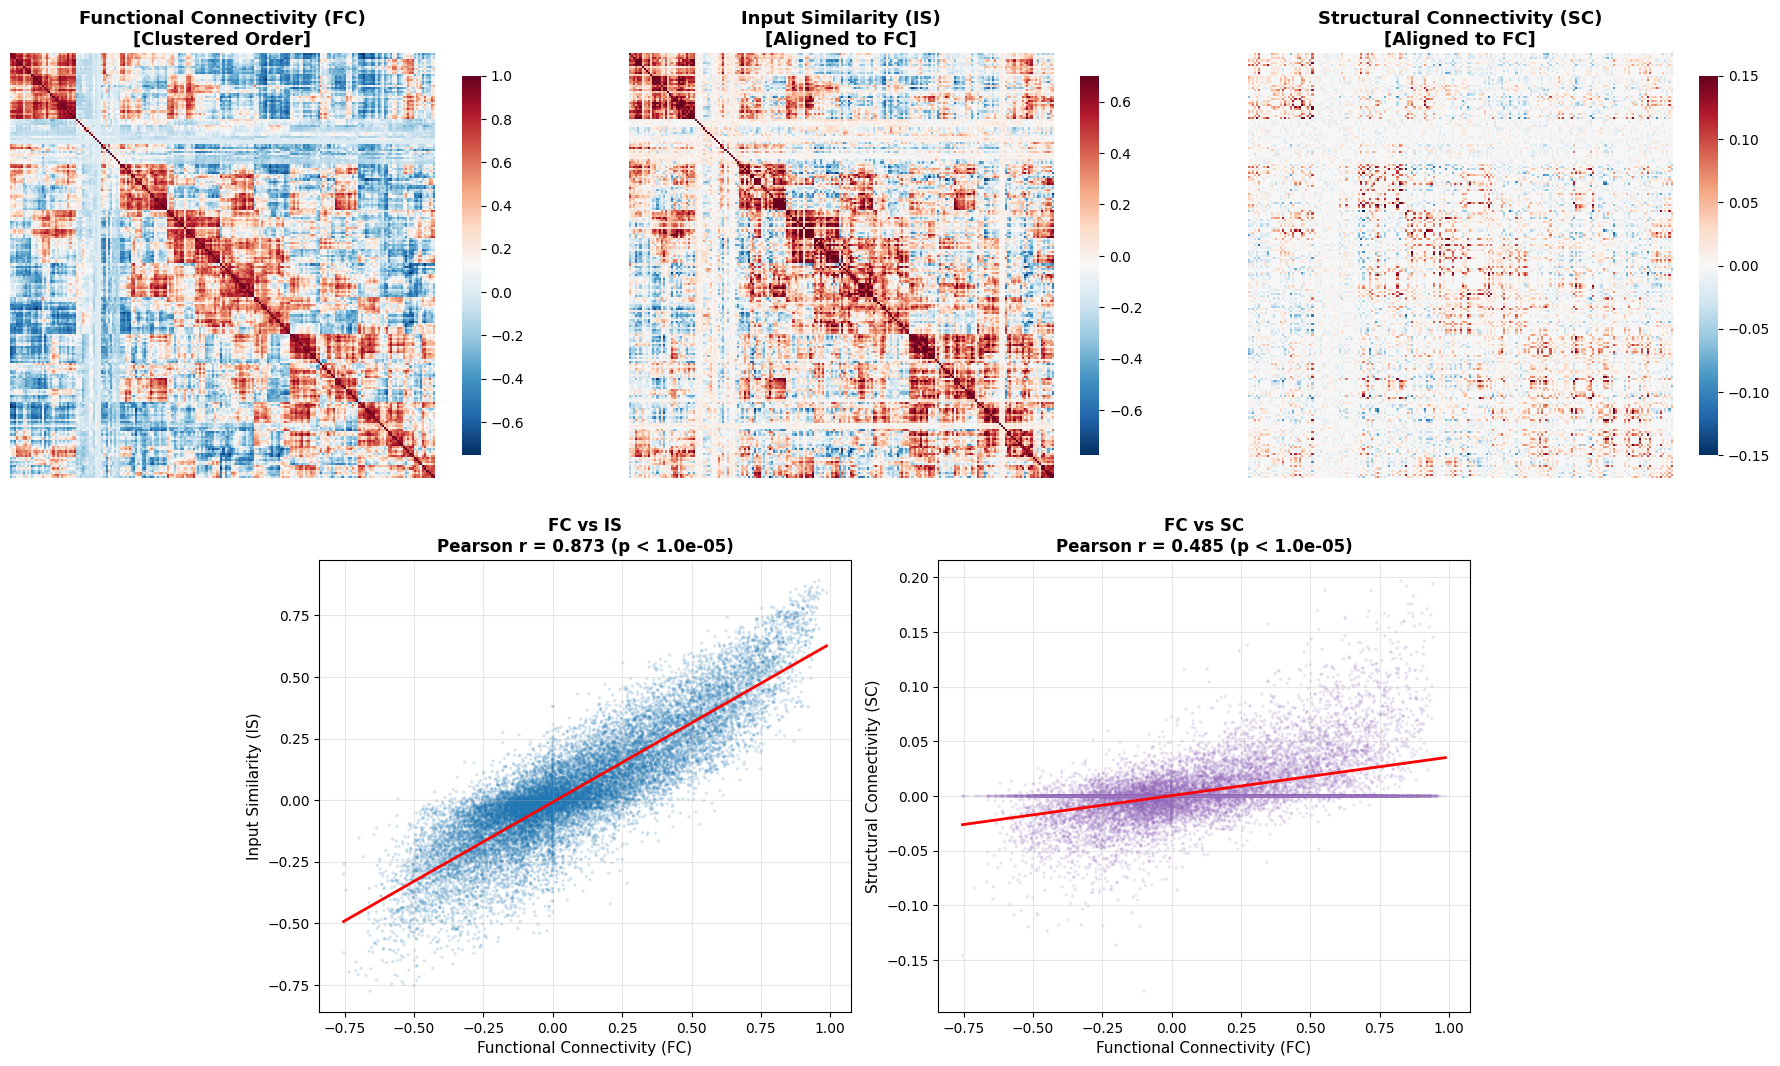

In [141]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist
from scipy import stats

def plot_multiplex_analysis(FC, IS, SC):
    """
    基于 FC 矩阵进行聚类重排热图，并绘制 FC-IS 与 FC-SC 的相关性散点图。
    """
    # ==========================================
    # 1. 计算层次聚类并获取对齐索引
    # ==========================================
    dist_matrix = pdist(FC, metric='euclidean')
    linkage_matrix = hierarchy.linkage(dist_matrix, method='ward')
    ordered_idx = hierarchy.leaves_list(linkage_matrix)
    
    # 重排矩阵
    FC_ordered = FC[ordered_idx, :][:, ordered_idx]
    IS_ordered = IS[ordered_idx, :][:, ordered_idx]
    SC_ordered = SC[ordered_idx, :][:, ordered_idx]
    
    # ==========================================
    # 2. 设置画布布局 (GridSpec: 上排 3 图，下排居中 2 图)
    # ==========================================
    fig = plt.figure(figsize=(18, 11))
    gs = fig.add_gridspec(2, 6, height_ratios=[1.2, 1])
    
    # 第一排：三个热图
    ax_fc = fig.add_subplot(gs[0, 0:2])
    ax_is = fig.add_subplot(gs[0, 2:4])
    ax_sc = fig.add_subplot(gs[0, 4:6])
    
    # 第二排：两个散点图居中分布
    ax_scatter_is = fig.add_subplot(gs[1, 1:3])
    ax_scatter_sc = fig.add_subplot(gs[1, 3:5])

    # ==========================================
    # 3. 绘制重排后的热图
    # ==========================================
    cmap_corr = 'RdBu_r'
    cmap_weight = 'RdBu_r' 
    
    sns.heatmap(FC_ordered, ax=ax_fc, cmap=cmap_corr, square=True, cbar_kws={"shrink": .7})
    ax_fc.set_title('Functional Connectivity (FC)\n[Clustered Order]', fontsize=13, fontweight='bold')
    
    sns.heatmap(IS_ordered, ax=ax_is, cmap=cmap_weight, square=True, cbar_kws={"shrink": .7}, vmax=0.7)
    ax_is.set_title('Input Similarity (IS)\n[Aligned to FC]', fontsize=13, fontweight='bold')
    
    sns.heatmap(SC_ordered, ax=ax_sc, cmap=cmap_weight, square=True, cbar_kws={"shrink": .7}, vmax=0.15, vmin=-0.15)
    ax_sc.set_title('Structural Connectivity (SC)\n[Aligned to FC]', fontsize=13, fontweight='bold')
    
    # 隐藏热图的坐标轴刻度
    for ax in [ax_fc, ax_is, ax_sc]:
        ax.set_xticks([])
        ax.set_yticks([])

    # ==========================================
    # 4. 提取散点图数据 (关键步骤：剔除对角线上的自身连接)
    # ==========================================
    num_neurons = FC.shape[0]
    off_diag_mask = ~np.eye(num_neurons, dtype=bool)
    
    # 展平非对角线元素 (总计 N*(N-1) 个数据点)
    fc_flat = FC[off_diag_mask]
    is_flat = IS[off_diag_mask]
    sc_flat = SC[off_diag_mask]
    
    # 计算皮尔逊相关系数和 P 值
    r_is, pval_is = stats.pearsonr(fc_flat, is_flat)
    r_sc, pval_sc = stats.pearsonr(fc_flat, sc_flat)

    # ==========================================
    # 5. 绘制散点图
    # ==========================================
    # 散点图透明度设为低值 (alpha=0.1)，防止数万个点重叠成黑色一团
    scatter_kwargs = {'alpha': 0.1, 's': 5, 'edgecolors': 'none'}
    line_kwargs = {'color': 'red', 'linewidth': 2}
    
    # FC vs IS
    ax_scatter_is.scatter(fc_flat, is_flat, color='tab:blue', **scatter_kwargs)
    sns.regplot(x=fc_flat, y=is_flat, ax=ax_scatter_is, scatter=False, line_kws=line_kwargs)
    ax_scatter_is.set_title(f'FC vs IS\nPearson r = {r_is:.3f} (p < {max(pval_is, 1e-5):.1e})', 
                            fontsize=12, fontweight='bold')
    ax_scatter_is.set_xlabel('Functional Connectivity (FC)', fontsize=11)
    ax_scatter_is.set_ylabel('Input Similarity (IS)', fontsize=11)
    ax_scatter_is.grid(True, alpha=0.3)
    
    # FC vs SC
    ax_scatter_sc.scatter(fc_flat, sc_flat, color='tab:purple', **scatter_kwargs)
    sns.regplot(x=fc_flat, y=sc_flat, ax=ax_scatter_sc, scatter=False, line_kws=line_kwargs)
    ax_scatter_sc.set_title(f'FC vs SC\nPearson r = {r_sc:.3f} (p < {max(pval_sc, 1e-5):.1e})', 
                            fontsize=12, fontweight='bold')
    ax_scatter_sc.set_xlabel('Functional Connectivity (FC)', fontsize=11)
    ax_scatter_sc.set_ylabel('Structural Connectivity (SC)', fontsize=11)
    ax_scatter_sc.grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.savefig('./fig/FC_SC_IS_compare.png', dpi=600, bbox_inches='tight')
    plt.show()
    
    return ordered_idx

# 调用示例：
ordered_indices = plot_multiplex_analysis(FC_mat, IS_mat, SC_mat)

### 2. Plotting training dynamic curves

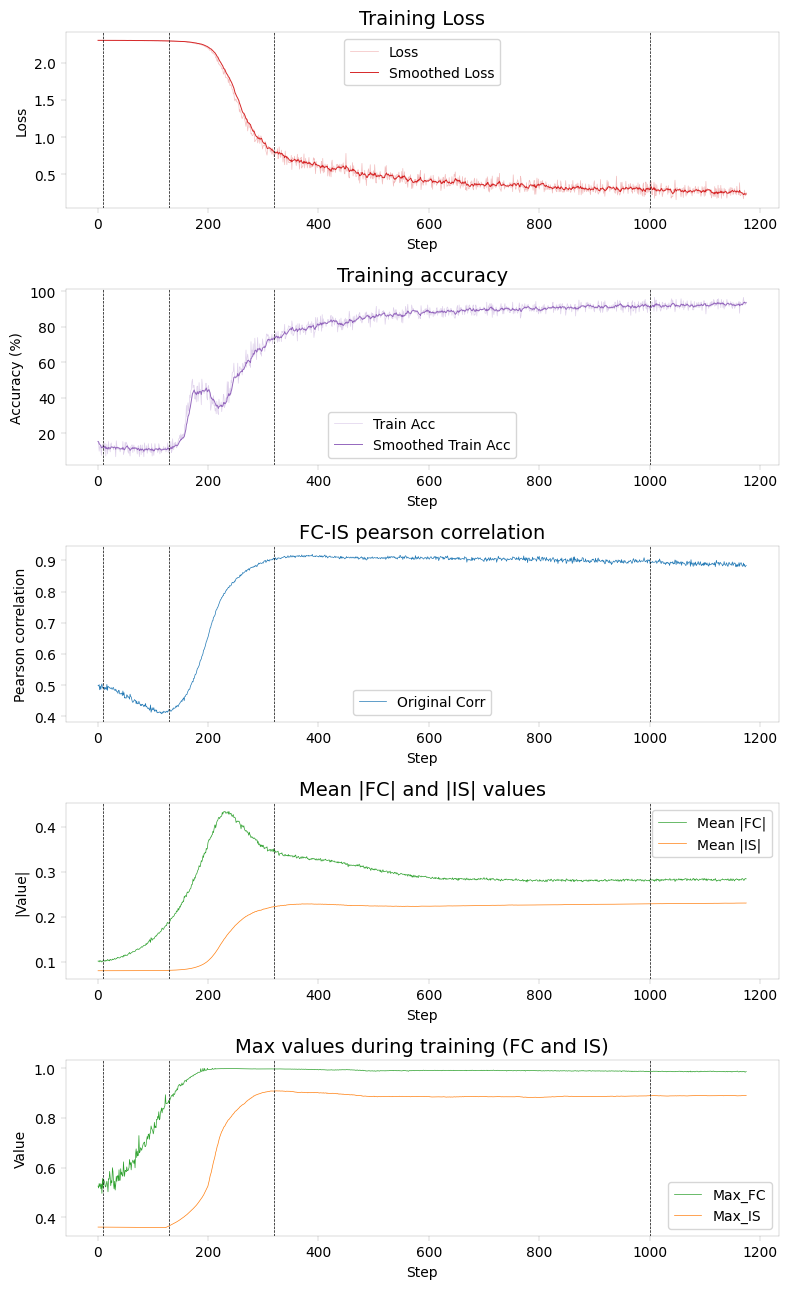

In [3]:
import matplotlib.pyplot as plt

def smooth_curve(scalars, weight=0.85):
    """
    使用指数移动平均 (EMA) 平滑数据。
    权重 (weight) 越大，曲线越平滑，取值范围通常在 0.8 到 0.99 之间。
    """
    if not scalars:
        return scalars
        
    last = scalars[0]
    smoothed = []
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
        
    return smoothed

def plot_curves(train_losses, train_accuracies, 
                         is_fc_proportion, is_fc_corr,
                         fc_max_values, scc_max_values,
                         test_accuracies=None, 
                         vertical_line_at=None, smoothing_weight=0.85, 
                         save_path=None):
    """Plot training dynamic parameters in 4 vertical subplots
    
    Args:
        train_losses: 训练损失列表
        train_accuracies: 训练准确率列表
        is_fc_proportion: Proportion of FC > 0.6 pairs 列表
        is_fc_corr: IS-FC Pearson Corr 列表
        test_accuracies: 可选的测试准确率列表
        vertical_line_at: 单个数值或数值列表，用于绘制竖线
        smoothing_weight: 平滑权重，越接近 1 越平滑
        save_path: 图片保存路径
    """
    # 调整为 5 行 1 列，增加高度以保证每个图足够清晰
    fig, axes = plt.subplots(5, 1, figsize=(8, 13))
    ax1, ax2, ax3, ax4, ax5 = axes
    
    epochs = range(1, len(train_losses) + 1)
    
    # 统一处理 vertical_line_at 为列表格式
    v_lines = []
    if vertical_line_at is not None:
        if isinstance(vertical_line_at, (int, float)):
            v_lines = [vertical_line_at]
        elif isinstance(vertical_line_at, (list, tuple)):
            v_lines = vertical_line_at

    # ====================
    # 1. 绘制 Loss 曲线 (ax1)
    # ====================
    ax1.plot(epochs, train_losses, color='tab:red', alpha=0.3, label='Loss', linewidth=0.5)
    smoothed_losses = smooth_curve(train_losses, weight=smoothing_weight)
    ax1.plot(epochs, smoothed_losses, color='tab:red', linewidth=0.7, label='Smoothed Loss')
    ax1.set_title('Training Loss', fontsize=14)
    ax1.set_ylabel('Loss')
    
    # ====================
    # 2. 绘制 Accuracy 曲线 (ax2)
    # ====================
    ax2.plot(epochs, train_accuracies, color='tab:purple', alpha=0.3, label='Train Acc', linewidth=0.5)
    smoothed_train_acc = smooth_curve(train_accuracies, weight=smoothing_weight)
    ax2.plot(epochs, smoothed_train_acc, color='tab:purple', linewidth=0.7, label='Smoothed Train Acc')
    
    if test_accuracies is not None:
        test_epochs = range(1, len(test_accuracies) + 1)
        ax2.plot(test_epochs, test_accuracies, color='tab:blue', alpha=0.3, label='Original Test Acc')
        smoothed_test_acc = smooth_curve(test_accuracies, weight=smoothing_weight)
        ax2.plot(test_epochs, smoothed_test_acc, color='tab:blue', linewidth=2, label='Smoothed Test Acc')
        
    ax2.set_title('Training accuracy', fontsize=14)
    ax2.set_ylabel('Accuracy (%)')

    # ====================
    # 3. 绘制 IS-FC Pearson Corr (ax3)
    # ====================
    ax3.plot(epochs, is_fc_corr, color='tab:blue', alpha=1, label='Original Corr', linewidth=0.5)
    # smoothed_corr = smooth_curve(is_fc_corr, weight=smoothing_weight)
    # ax3.plot(epochs, smoothed_corr, color='tab:orange', linewidth=2, label='Smoothed Corr')
    ax3.set_title('FC-IS pearson correlation', fontsize=14)
    ax3.set_ylabel('Pearson correlation')

    # ====================
    # 4. 绘制 Proportion of FC > 0.6 pairs (ax4)
    # ====================
    ax4.plot(epochs, fc_mean_abs_values, color='tab:green', alpha=1, label='Mean |FC|', linewidth=0.5)
    ax4.plot(epochs, is_mean_abs_values, color='tab:orange', alpha=1, label='Mean |IS|', linewidth=0.5)
    # smoothed_fc = smooth_curve(fc_proportion, weight=smoothing_weight)
    # ax4.plot(epochs, smoothed_fc, color='tab:green', linewidth=2, label='Smoothed Proportion')
    ax4.set_title('Mean |FC| and |IS| values', fontsize=14)
    ax4.set_ylabel('|Value|')
    # ax4.set_ylim(0, 15) 

    # ====================
    # 5. 绘制其他指标 (ax5)
    # ====================
    ax5.plot(epochs, fc_max_values, color='tab:green', alpha=1, label='Max_FC', linewidth=0.5)
    ax5.plot(epochs, scc_max_values, color='tab:orange', alpha=1, label='Max_IS', linewidth=0.5)
    ax5.set_title('Max values during training (FC and IS)', fontsize=14)
    ax5.set_ylabel('Value')

    # ====================
    # 统一处理所有子图的公共部分：竖线、X轴标签、网格和图例
    # ====================
    border_width = 0.25      # 边框粗细
    border_alpha = 0.4      # 边框透明度 (0到1之间)
    tick_width = 0.25       # 刻度线粗细
    tick_alpha = 0.4        # 刻度线透明度 (通过 RGBA 颜色实现)
    for ax in axes:
        # 绘制竖线并去重图例
        vline_labeled = False
        for v_line in v_lines:
            label = f'Step {v_line}' if not vline_labeled else None
            ax.axvline(x=v_line, color='black', linestyle='--', linewidth=0.5)
            vline_labeled = True
            
        ax.set_xlabel('Step')
        # ax.grid(True, alpha=0.3)  # 加入浅色网格有助于对齐查看上下图
        ax.legend(loc='best')

        for spine in ax.spines.values():
            spine.set_linewidth(border_width)
            spine.set_alpha(border_alpha)
            
        # 2. 调节刻度线 (ticks) 的粗细、长度和透明度
        # 注意：tick_params 中没有直接的 alpha 参数，需要通过传入带 alpha 通道的 RGBA 颜色来实现透明度
        # (0, 0, 0, tick_alpha) 代表黑色，带有指定的透明度
        ax.tick_params(axis='both', 
                       which='major', 
                       width=tick_width, 
                       color=(0, 0, 0, tick_alpha))
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, format='pdf')
    plt.show()

plot_curves(train_losses, train_accuracies,
            fc_is_proportion, corr_values,
            fc_max_values, scc_max_values,
            vertical_line_at=[10, 130, 320, 1000],
            smoothing_weight=0.8,
            save_path=f'./fig/training_dynamics.pdf'
            )

### network during training


========== Early | step=130 | top edges=40.00% ==========
IS threshold: 0.085 | edges: 970 | metrics: {'density': 0.196, 'clustering': 0.2526, 'mean_degree': np.float64(19.4), 'weighted_clustering': 0.0986, 'weighted_mean_degree': np.float64(2.783), 'modularity': 0.303, 'n_modules': 3}
FC threshold: 0.237 | edges: 973 | metrics: {'density': 0.1966, 'clustering': 0.5752, 'mean_degree': np.float64(19.46), 'weighted_clustering': 0.2845, 'weighted_mean_degree': np.float64(8.5905), 'modularity': 0.4993, 'n_modules': 12}


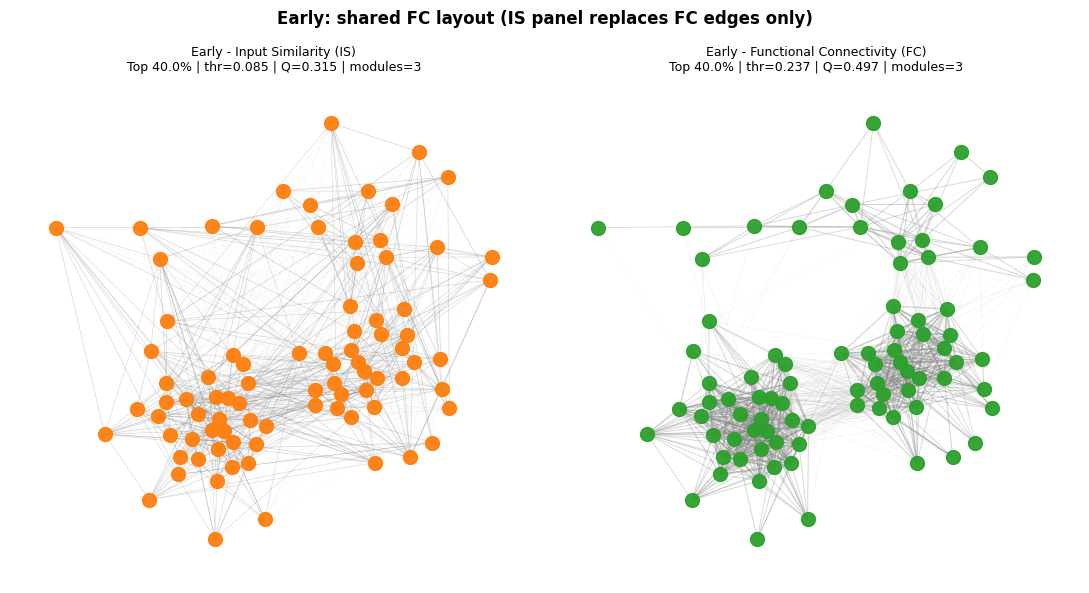


========== Middle | step=320 | top edges=40.00% ==========
IS threshold: 0.2593 | edges: 963 | metrics: {'density': 0.1945, 'clustering': 0.605, 'mean_degree': np.float64(19.26), 'weighted_clustering': 0.3266, 'weighted_mean_degree': np.float64(9.3991), 'modularity': 0.5499, 'n_modules': 13}
FC threshold: 0.6288 | edges: 921 | metrics: {'density': 0.1861, 'clustering': 0.6344, 'mean_degree': np.float64(18.42), 'weighted_clustering': 0.5318, 'weighted_mean_degree': np.float64(15.1334), 'modularity': 0.6192, 'n_modules': 16}


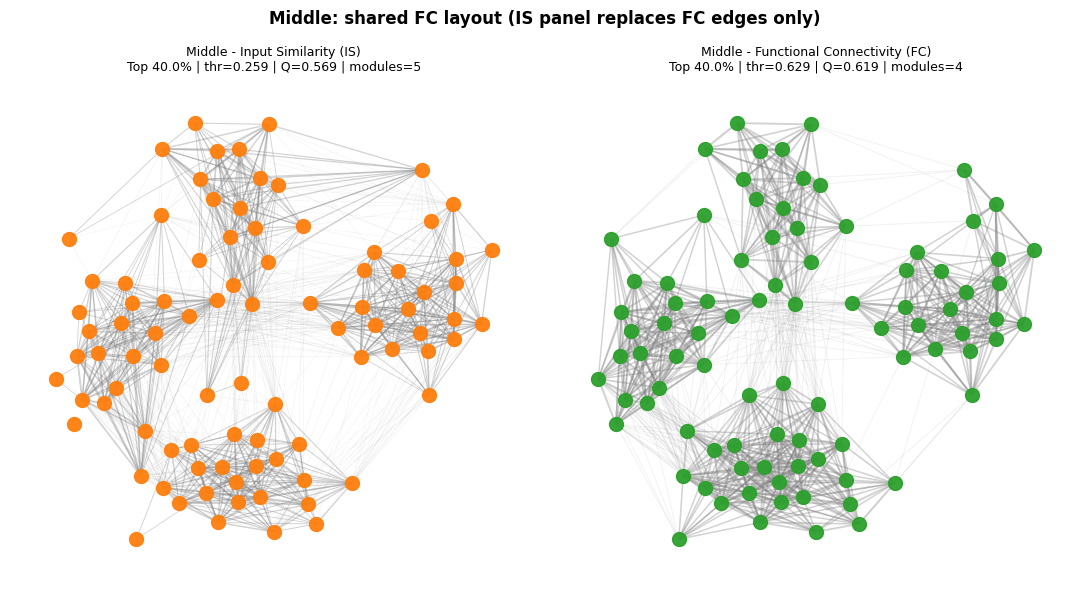


========== Late | step=1174 | top edges=40.00% ==========
IS threshold: 0.2665 | edges: 974 | metrics: {'density': 0.1968, 'clustering': 0.5035, 'mean_degree': np.float64(19.48), 'weighted_clustering': 0.2756, 'weighted_mean_degree': np.float64(9.2492), 'modularity': 0.4983, 'n_modules': 11}
FC threshold: 0.4132 | edges: 1092 | metrics: {'density': 0.2206, 'clustering': 0.5711, 'mean_degree': np.float64(21.84), 'weighted_clustering': 0.3824, 'weighted_mean_degree': np.float64(13.9936), 'modularity': 0.5123, 'n_modules': 12}


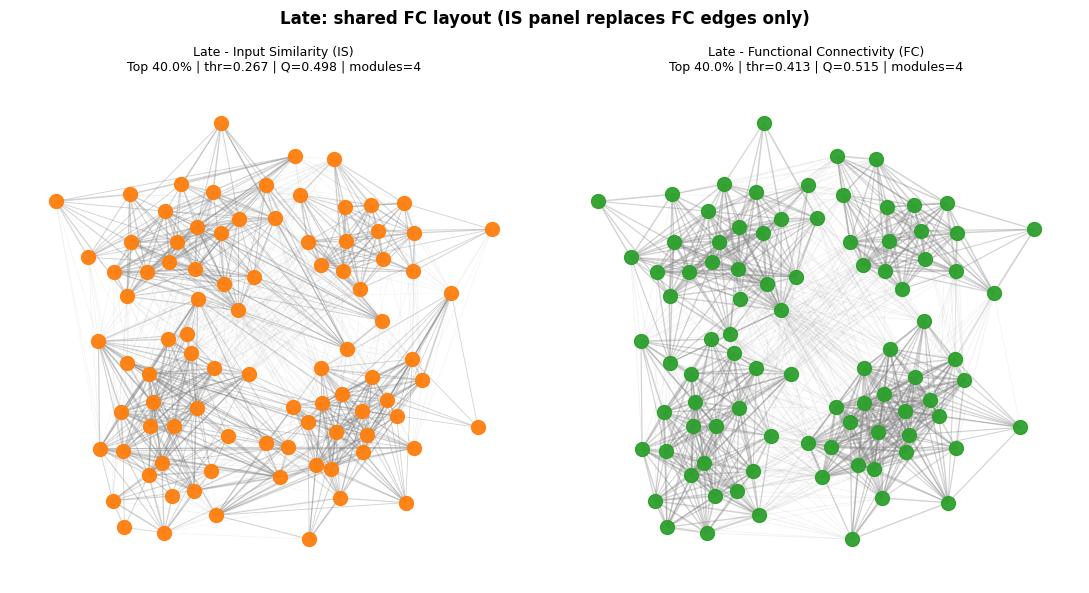

In [12]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities, modularity

def collect_fixed_balanced_inputs(data_loader, samples_per_class=100, num_classes=10):
    class_samples = {c: [] for c in range(num_classes)}
    for batch_x, batch_y in data_loader:
        for x, y in zip(batch_x, batch_y):
            c = int(y)
            if len(class_samples[c]) < samples_per_class:
                class_samples[c].append(x.detach().cpu().clone())
        if all(len(class_samples[c]) >= samples_per_class for c in range(num_classes)):
            break
    missing = {c: samples_per_class - len(v) for c, v in class_samples.items() if len(v) < samples_per_class}
    if missing:
        raise ValueError("Not enough samples for some classes: " + str(missing))
    return torch.stack([x for c in range(num_classes) for x in class_samples[c][:samples_per_class]])

def get_layer_fc_from_fixed_inputs(model, fixed_inputs, layer_idx=1, batch_size=256):
    device = next(model.parameters()).device
    acts = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(fixed_inputs), batch_size):
            batch = fixed_inputs[start:start+batch_size].to(device)
            hidden = model.get_hidden_activations(batch)
            acts.append(hidden[layer_idx].detach().cpu().numpy())
    act_mat = np.concatenate(acts, axis=0)
    return np.nan_to_num(np.corrcoef(act_mat.T), nan=0.0, posinf=0.0, neginf=0.0)

def build_graph_top_edges(matrix, top_prop=0.05, positive_only=True):
    n = matrix.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    triu_idx = np.triu_indices(n, k=1)
    values = np.nan_to_num(matrix[triu_idx])
    if positive_only:
        mask = values > 0
        values, ii, jj = values[mask], triu_idx[0][mask], triu_idx[1][mask]
    else:
        ii, jj = triu_idx[0], triu_idx[1]
    if len(values) == 0:
        return G, np.nan
    n_keep = min(max(int(np.ceil(len(values) * top_prop)), 1), len(values))
    top_idx = np.argsort(values)[-n_keep:]
    G.add_weighted_edges_from([(int(ii[k]), int(jj[k]), float(values[k])) for k in top_idx])
    return G, float(np.min(values[top_idx]))

def detect_communities(G, method="louvain", resolution=1.0, seed=0):
    if G.number_of_edges() == 0:
        comms = [{n} for n in G.nodes()]
        return comms, {n: i for i, n in enumerate(G.nodes())}, 0.0
    if method == "louvain" and hasattr(nx.community, "louvain_communities"):
        comms = list(nx.community.louvain_communities(
            G, weight="weight", resolution=resolution, seed=seed
        ))
    else:
        comms = list(greedy_modularity_communities(
            G, weight="weight", resolution=resolution
        ))
    node_to_comm = {n: i for i, c in enumerate(comms) for n in c}
    q = modularity(G, comms, weight="weight", resolution=resolution) if len(comms) > 1 else 0.0
    return comms, node_to_comm, float(q)

# def get_topology_layout(G, layout_type="kamada", seed=0):
#     if layout_type == "kamada":
#         return nx.kamada_kawai_layout(G, weight="weight")
#     if layout_type == "spring":
#         return nx.spring_layout(G, weight="weight", seed=seed, iterations=300)
#     if layout_type == "spectral":
#         return nx.spectral_layout(G, weight="weight")
#     if layout_type == "circular":
#         return nx.circular_layout(G)
#     return nx.kamada_kawai_layout(G, weight="weight")
def get_topology_layout(
    G,
    layout_type="kamada",
    seed=0,
    community_method="louvain",
    resolution=1.0,
    module_gap=3.0,
):
    if layout_type == "kamada":
        _, node_to_comm, _ = detect_communities(
            G,
            method=community_method,
            resolution=resolution,
            seed=seed,
        )

        # 构造用于布局的距离图
        distance_graph = nx.Graph()
        distance_graph.add_nodes_from(G.nodes())

        for u, v, data in G.edges(data=True):
            similarity = max(float(data.get("weight", 1.0)), 1e-6)

            # 相关性越强，距离越短
            distance = 1.0 / similarity

            # 不同模块之间进一步拉开
            if node_to_comm[u] != node_to_comm[v]:
                distance *= module_gap

            distance_graph.add_edge(u, v, distance=distance)

        distances = dict(
            nx.all_pairs_dijkstra_path_length(
                distance_graph,
                weight="distance",
            )
        )

        return nx.kamada_kawai_layout(
            G,
            dist=distances,
            weight=None,
            scale=1.0,
        )

    if layout_type == "spring":
        return nx.spring_layout(
            G,
            weight="weight",
            seed=seed,
            iterations=300,
        )

    if layout_type == "spectral":
        return nx.spectral_layout(G, weight="weight")

    if layout_type == "circular":
        return nx.circular_layout(G)

    return nx.kamada_kawai_layout(G)

def compute_selected_metrics(G, community_method="louvain", resolution=1.0, seed=0):
    comms, node_to_comm, q = detect_communities(
        G, method=community_method, resolution=resolution, seed=seed
    )
    degrees = np.array([d for _, d in G.degree()])
    w_degrees = np.array([d for _, d in G.degree(weight="weight")])
    return {
        "density": nx.density(G),
        "clustering": nx.average_clustering(G) if G.number_of_edges() > 0 else 0,
        "mean_degree": degrees.mean() if len(degrees) else 0,
        "weighted_clustering": nx.average_clustering(G, weight="weight") if G.number_of_edges() > 0 else 0,
        "weighted_mean_degree": w_degrees.mean() if len(w_degrees) else 0,
        "modularity": q,
        "n_modules": len(comms),
    }

def plot_one_network(
    ax,
    G,
    title,
    threshold,
    top_prop,
    fixed_nodes,
    fixed_pos,
    community_method="louvain",
    resolution=1.0,
    seed=0,
    node_color="tab:orange",
):
    """Draw G using the FC-selected nodes and the FC-computed positions."""
    Gp = G.subgraph(fixed_nodes).copy()

    comms, node_to_comm, q = detect_communities(
        Gp, method=community_method, resolution=resolution, seed=seed
    )
    pos = {node: fixed_pos[node] for node in Gp.nodes()}

    intra_edges, inter_edges = [], []
    for u, v in Gp.edges():
        if node_to_comm[u] == node_to_comm[v]:
            intra_edges.append((u, v))
        else:
            inter_edges.append((u, v))

    intra_widths = [0.25 + 1.2 * Gp[u][v].get("weight", 1.0) for u, v in intra_edges]
    inter_widths = [0.15 + 0.8 * Gp[u][v].get("weight", 1.0) for u, v in inter_edges]

    nx.draw_networkx_edges(
        Gp, pos, edgelist=inter_edges, ax=ax, width=inter_widths,
        alpha=0.10, edge_color="gray"
    )
    nx.draw_networkx_edges(
        Gp, pos, edgelist=intra_edges, ax=ax, width=intra_widths,
        alpha=0.35, edge_color="gray"
    )
    nx.draw_networkx_nodes(
        Gp, pos, ax=ax, node_size=100, node_color=node_color,
        cmap=plt.cm.Paired, alpha=0.95
    )

    ax.set_title(
        f"{title}\nTop {top_prop*100:.1f}% | thr={threshold:.3f} | "
        f"Q={q:.3f} | modules={len(comms)}",
        fontsize=9,
    )
    ax.axis("off")
    return {
        "graph": Gp,
        "communities": comms,
        "node_to_comm": node_to_comm,
        "modularity": q,
        "position": pos,
    }

def plot_network_comparison(
    G_is,
    G_fc,
    stage_name,
    t_is,
    t_fc,
    top_prop,
    layout_type="kamada",
    min_degree_plot=2,
    community_method="louvain",
    resolution=1.0,
    seed=0,
    module_gap=1.5,
):
    """Use FC to select nodes and compute one shared layout; IS only replaces edges."""
    fc_nodes = [n for n, degree in G_fc.degree() if degree >= min_degree_plot]
    if not fc_nodes:
        raise ValueError(
            f"{stage_name}: FC has no nodes with degree >= {min_degree_plot}; "
            "lower min_degree_plot."
        )

    G_fc_plot = G_fc.subgraph(fc_nodes).copy()
    if G_fc_plot.number_of_edges() == 0:
        raise ValueError(
            f"{stage_name}: FC has no edges after node filtering; "
            "lower min_degree_plot."
        )

    # The only layout calculation: both panels receive these FC coordinates.
    # fc_pos = get_topology_layout(G_fc_plot, layout_type=layout_type, seed=seed)
    fc_pos = get_topology_layout(
                                    G_fc_plot,
                                    layout_type=layout_type,
                                    seed=seed,
                                    community_method=community_method,
                                    resolution=resolution,
                                    module_gap=module_gap,
                                )
    fig, axes = plt.subplots(1, 2, figsize=(11, 6))
    out_is = plot_one_network(
        axes[0], G_is, f"{stage_name} - Input Similarity (IS)",
        t_is, top_prop, fixed_nodes=fc_nodes, fixed_pos=fc_pos,
        community_method=community_method, resolution=resolution, seed=seed,
        node_color="tab:orange",
    )
    out_fc = plot_one_network(
        axes[1], G_fc, f"{stage_name} - Functional Connectivity (FC)",
        t_fc, top_prop, fixed_nodes=fc_nodes, fixed_pos=fc_pos,
        community_method=community_method, resolution=resolution, seed=seed,
        node_color="tab:green",
    )

    plt.suptitle(
        f"{stage_name}: shared FC layout (IS panel replaces FC edges only)",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(f"./fig/{stage_name}_IS_FC_comparison.pdf", format="pdf")
    plt.show()
    return out_is, out_fc

def plot_metrics_bars(is_metrics_all, fc_metrics_all, step_names):
    metric_names = [
        "modularity", "n_modules", "clustering",
        "weighted_clustering", "mean_degree", "weighted_mean_degree",
    ]
    metric_titles = [
        "Modularity", "Number of modules", "Clustering",
        "Weighted clustering", "Mean degree", "Weighted mean degree",
    ]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    x = np.arange(len(step_names))
    width = 0.35
    for ax, metric, title in zip(axes.ravel(), metric_names, metric_titles):
        is_vals = [m[metric] for m in is_metrics_all]
        fc_vals = [m[metric] for m in fc_metrics_all]
        b1 = ax.bar(x - width/2, is_vals, width, label="IS", color="#FFB3BA", edgecolor="black")
        b2 = ax.bar(x + width/2, fc_vals, width, label="FC", color="#BAE1FF", edgecolor="black")
        ax.set_title(title, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(step_names)
        ax.legend(frameon=False)
        for bars in [b1, b2]:
            for r in bars:
                h = r.get_height()
                label = f"{int(h)}" if metric == "n_modules" else f"{h:.3f}"
                ax.annotate(
                    label, xy=(r.get_x()+r.get_width()/2, h), xytext=(0, 3),
                    textcoords="offset points", ha="center", va="bottom", fontsize=8
                )
    plt.suptitle("IS vs FC network topology with community detection", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

def analyze_is_fc_topology(
    models,
    fixed_inputs,
    input_size=784,
    hidden_dims=[100, 100],
    step_early=130,
    step_middle=320,
    step_late=-1,
    top_props=[0.05, 0.05, 0.05],
    positive_only=True,
    layout_type="kamada",
    min_degree_plot=2,
    community_method="louvain",
    resolution=1.0,
    seed=1,
    module_gap=1.5
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if step_late == -1:
        step_late = len(models) - 1
    steps = [step_early, step_middle, step_late]
    step_names = ["Early", "Middle", "Late"]
    if len(top_props) != 3:
        raise ValueError("top_props must contain three values: [early, middle, late].")
    is_metrics_all, fc_metrics_all, network_outputs = [], [], {}

    for step, stage, top_prop in zip(steps, step_names, top_props):
        print(f"\n========== {stage} | step={step} | top edges={top_prop*100:.2f}% ==========")
        model = MLP(input_size=input_size, hidden_dims=hidden_dims)
        model.load_state_dict(models[step])
        model.to(device)
        model.eval()

        weights = model.linear_layers[1].weight.detach().cpu().numpy()
        is_matrix = np.nan_to_num(np.corrcoef(weights))

        fc_matrix = get_layer_fc_from_fixed_inputs(
            model, fixed_inputs=fixed_inputs, layer_idx=1, batch_size=256
        )

        G_is, t_is = build_graph_top_edges(
            is_matrix, top_prop=top_prop, positive_only=positive_only
        )
        G_fc, t_fc = build_graph_top_edges(
            fc_matrix, top_prop=top_prop, positive_only=positive_only
        )

        is_metrics = compute_selected_metrics(
            G_is, community_method=community_method, resolution=resolution, seed=seed
        )
        fc_metrics = compute_selected_metrics(
            G_fc, community_method=community_method, resolution=resolution, seed=seed
        )
        is_metrics_all.append(is_metrics)
        fc_metrics_all.append(fc_metrics)

        print("IS threshold:", round(t_is, 4), "| edges:", G_is.number_of_edges(), "| metrics:", {k: round(v, 4) for k, v in is_metrics.items()})
        print("FC threshold:", round(t_fc, 4), "| edges:", G_fc.number_of_edges(), "| metrics:", {k: round(v, 4) for k, v in fc_metrics.items()})

        out_is, out_fc = plot_network_comparison(
            G_is, G_fc, stage, t_is, t_fc, top_prop,
            layout_type=layout_type, min_degree_plot=min_degree_plot,
            community_method=community_method, resolution=resolution, seed=seed, module_gap=module_gap
        )
        network_outputs[stage] = {
            "IS": out_is, "FC": out_fc, "G_is": G_is, "G_fc": G_fc,
            "t_is": t_is, "t_fc": t_fc,
        }

    return is_metrics_all, fc_metrics_all, network_outputs

set_seed(42)

fixed_inputs = collect_fixed_balanced_inputs(
    train_loader,
    samples_per_class=100,
    num_classes=10,
)

is_results, fc_results, network_outputs = analyze_is_fc_topology(
    models=models,
    fixed_inputs=fixed_inputs,
    input_size=input_size,
    hidden_dims=hidden_dims,
    step_early=130,
    step_middle=320,
    step_late=len(models)-1,
    top_props=[0.4, 0.4, 0.4],
    positive_only=True,
    layout_type= 'kamada',   # "spring",
    min_degree_plot=3,
    community_method="louvain",
    resolution=0.75,
    seed=0,
    module_gap=1.5
)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
from scipy.ndimage import gaussian_filter1d
from tqdm.auto import tqdm


def collect_fixed_balanced_inputs(data_loader, samples_per_class=100, num_classes=10):
    """Collect one fixed, class-balanced evaluation set for all model snapshots."""
    class_samples = {class_id: [] for class_id in range(num_classes)}

    for batch_x, batch_y in data_loader:
        for x, y in zip(batch_x, batch_y):
            class_id = int(y)
            if len(class_samples[class_id]) < samples_per_class:
                class_samples[class_id].append(x.detach().cpu().clone())

        if all(len(values) >= samples_per_class for values in class_samples.values()):
            break

    missing = {
        class_id: samples_per_class - len(values)
        for class_id, values in class_samples.items()
        if len(values) < samples_per_class
    }
    if missing:
        raise ValueError("Not enough samples for some classes: " + str(missing))

    fixed_x = torch.stack([
        x
        for class_id in range(num_classes)
        for x in class_samples[class_id][:samples_per_class]
    ])
    fixed_y = np.repeat(np.arange(num_classes), samples_per_class)
    return fixed_x, fixed_y


def get_layer_fc_from_fixed_inputs(model, fixed_inputs, layer_idx=1, batch_size=256):
    """Compute FC for one hidden layer using exactly the same inputs at every step."""
    device = next(model.parameters()).device
    activation_batches = []

    model.eval()
    with torch.no_grad():
        for start in range(0, len(fixed_inputs), batch_size):
            batch = fixed_inputs[start:start + batch_size].to(device)
            layer_activations = model.get_hidden_activations(batch)
            activation_batches.append(layer_activations[layer_idx].detach().cpu().numpy())

    activation_matrix = np.concatenate(activation_batches, axis=0)
    fc_matrix = np.corrcoef(activation_matrix.T)
    return np.nan_to_num(fc_matrix, nan=0.0, posinf=0.0, neginf=0.0)


def extract_fixed_fc_is_history(
    model_states,
    fixed_inputs,
    input_size,
    hidden_dims,
    num_classes=10,
    act="relu",
    layer_idx=1,
    step_interval=1,
    inference_batch_size=256,
):
    """Extract vectorized FC and IS histories with a fixed FC evaluation set."""
    if step_interval < 1:
        raise ValueError("step_interval must be >= 1")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    template = MLP(
        input_size=input_size,
        hidden_dims=hidden_dims,
        num_classes=num_classes,
        activation=act,
        init=False,
    ).to(device)

    n_nodes = hidden_dims[layer_idx]
    triu = np.triu_indices(n_nodes, k=1)

    sampled_steps = []
    fc_history = []
    is_history = []

    snapshot_indices = range(0, len(model_states), step_interval)
    for state_idx in tqdm(snapshot_indices, desc="Fixed-sample FC/IS history"):
        template.load_state_dict(model_states[state_idx])
        template.eval()

        weight_matrix = (
            template.linear_layers[layer_idx]
            .weight.detach().cpu().numpy()
        )
        is_matrix = np.corrcoef(weight_matrix)
        is_matrix = np.nan_to_num(is_matrix, nan=0.0, posinf=0.0, neginf=0.0)

        fc_matrix = get_layer_fc_from_fixed_inputs(
            template,
            fixed_inputs=fixed_inputs,
            layer_idx=layer_idx,
            batch_size=inference_batch_size,
        )

        sampled_steps.append(state_idx)
        fc_history.append(fc_matrix[triu].astype(np.float32))
        is_history.append(is_matrix[triu].astype(np.float32))

    return (
        np.asarray(sampled_steps),
        np.asarray(fc_history),
        np.asarray(is_history),
    )


# Use every saved training step for the final figure.
# Set to 5 only when a faster preview is needed.
MODULE_STEP_INTERVAL = 10
MODULE_SAMPLES_PER_CLASS = 100

fixed_module_inputs, fixed_module_targets = collect_fixed_balanced_inputs(
    train_loader,
    samples_per_class=MODULE_SAMPLES_PER_CLASS,
    num_classes=10,
)

module_steps, module_fc_hist, module_is_hist = extract_fixed_fc_is_history(
    model_states=models,
    fixed_inputs=fixed_module_inputs,
    input_size=input_size,
    hidden_dims=hidden_dims,
    num_classes=10,
    act=act,
    layer_idx=1,
    step_interval=MODULE_STEP_INTERVAL,
    inference_batch_size=256,
)

print("Module-history shapes:", module_steps.shape, module_fc_hist.shape, module_is_hist.shape)

Fixed-sample FC/IS history:   0%|          | 0/118 [00:00<?, ?it/s]

Module-history shapes: (118,) (118, 4950) (118, 4950)


FC/IS top-edge modularity:   0%|          | 0/118 [00:00<?, ?it/s]

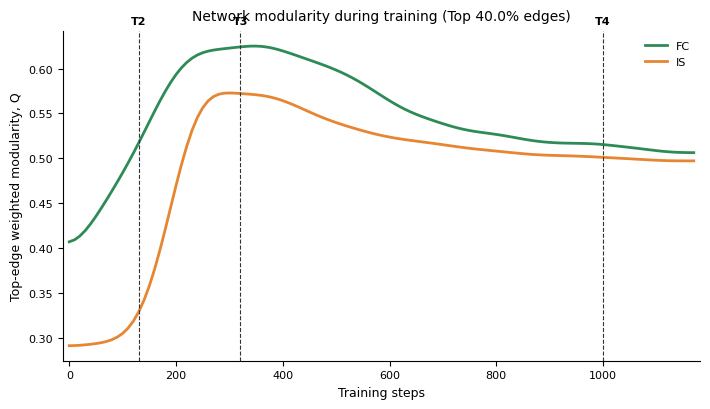

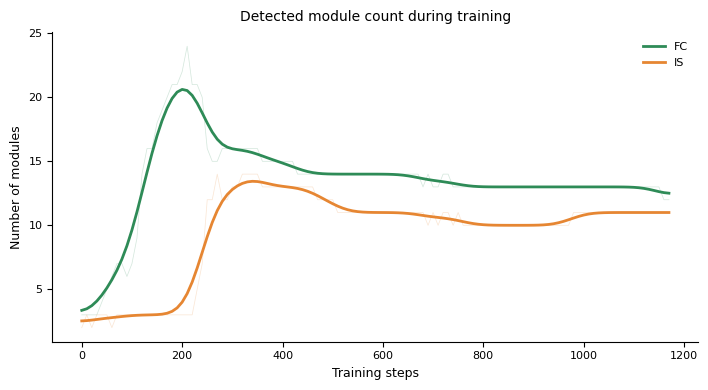

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.ndimage import gaussian_filter1d
from tqdm.auto import tqdm

def infer_node_count_from_vector_length(vector_length):
    n_nodes = int((1 + np.sqrt(1 + 8 * vector_length)) / 2)
    if n_nodes * (n_nodes - 1) // 2 != vector_length:
        raise ValueError("Invalid upper-triangle vector length: " + str(vector_length))
    return n_nodes

def vector_to_symmetric_matrix(vector):
    vector = np.asarray(vector)
    n_nodes = infer_node_count_from_vector_length(vector.size)
    matrix = np.zeros((n_nodes, n_nodes), dtype=float)
    triu = np.triu_indices(n_nodes, k=1)
    matrix[triu] = vector
    matrix[(triu[1], triu[0])] = vector
    return matrix

def build_top_edge_graph(matrix, top_prop=0.05, positive_only=True):
    matrix = np.asarray(matrix, dtype=float).copy()
    matrix[~np.isfinite(matrix)] = 0.0
    np.fill_diagonal(matrix, 0.0)
    n_nodes = matrix.shape[0]
    graph = nx.Graph()
    graph.add_nodes_from(range(n_nodes))

    triu = np.triu_indices(n_nodes, k=1)
    values = matrix[triu]

    if positive_only:
        mask = values > 0
        values = values[mask]
        rows = triu[0][mask]
        cols = triu[1][mask]
    else:
        rows = triu[0]
        cols = triu[1]

    if len(values) == 0:
        return graph, np.nan

    n_keep = int(np.ceil(len(values) * top_prop))
    n_keep = min(max(n_keep, 1), len(values))
    top_idx = np.argsort(values)[-n_keep:]

    edges = [
        (int(rows[idx]), int(cols[idx]), float(values[idx]))
        for idx in top_idx
    ]
    graph.add_weighted_edges_from(edges)

    actual_threshold = float(np.min(values[top_idx]))
    return graph, actual_threshold

def best_top_edge_modularity(
    matrix,
    top_prop=0.05,
    positive_only=True,
    resolution=1.0,
    n_repeats=5,
    random_seed=0,
):
    graph, actual_threshold = build_top_edge_graph(
        matrix,
        top_prop=top_prop,
        positive_only=positive_only,
    )

    if graph.number_of_edges() == 0:
        return 0.0, 0, actual_threshold, graph

    best_q = -np.inf
    best_n_modules = 0
    has_louvain = hasattr(nx.community, "louvain_communities")
    repeats = max(1, int(n_repeats)) if has_louvain else 1

    for repeat_idx in range(repeats):
        if has_louvain:
            communities = nx.community.louvain_communities(
                graph,
                weight="weight",
                resolution=resolution,
                seed=random_seed + repeat_idx,
            )
        else:
            communities = nx.community.greedy_modularity_communities(
                graph,
                weight="weight",
                resolution=resolution,
            )

        q_value = nx.community.modularity(
            graph,
            communities,
            weight="weight",
            resolution=resolution,
        )

        if q_value > best_q:
            best_q = float(q_value)
            best_n_modules = len(communities)

    return best_q, best_n_modules, actual_threshold, graph

def compute_fc_is_top_edge_modularity_history(
    sampled_steps,
    fc_history,
    is_history,
    top_prop=0.05,
    positive_only=True,
    resolution=1.0,
    n_repeats=5,
    random_seed=0,
):
    sampled_steps = np.asarray(sampled_steps)
    fc_history = np.asarray(fc_history)
    is_history = np.asarray(is_history)

    if fc_history.shape != is_history.shape:
        raise ValueError("FC and IS histories must have the same shape")
    if len(sampled_steps) != fc_history.shape[0]:
        raise ValueError("sampled_steps and history length do not match")

    q_fc = np.empty(len(sampled_steps), dtype=float)
    q_is = np.empty(len(sampled_steps), dtype=float)
    n_fc = np.empty(len(sampled_steps), dtype=int)
    n_is = np.empty(len(sampled_steps), dtype=int)
    thr_fc = np.empty(len(sampled_steps), dtype=float)
    thr_is = np.empty(len(sampled_steps), dtype=float)

    for time_idx in tqdm(range(len(sampled_steps)), desc="FC/IS top-edge modularity"):
        fc_matrix = vector_to_symmetric_matrix(fc_history[time_idx])
        is_matrix = vector_to_symmetric_matrix(is_history[time_idx])

        q_fc[time_idx], n_fc[time_idx], thr_fc[time_idx], _ = best_top_edge_modularity(
            fc_matrix,
            top_prop=top_prop,
            positive_only=positive_only,
            resolution=resolution,
            n_repeats=n_repeats,
            random_seed=random_seed + 1000 * time_idx,
        )

        q_is[time_idx], n_is[time_idx], thr_is[time_idx], _ = best_top_edge_modularity(
            is_matrix,
            top_prop=top_prop,
            positive_only=positive_only,
            resolution=resolution,
            n_repeats=n_repeats,
            random_seed=random_seed + 1000 * time_idx + 500000,
        )

    return {
        "steps": sampled_steps,
        "q_fc": q_fc,
        "q_is": q_is,
        "n_fc": n_fc,
        "n_is": n_is,
        "threshold_fc": thr_fc,
        "threshold_is": thr_is,
        "top_prop": top_prop,
        "positive_only": positive_only,
        "resolution": resolution,
        "n_repeats": n_repeats,
    }

def plot_fc_is_top_edge_modularity_curves(
    result,
    t2=130,
    t3=320,
    t4=1000,
    smooth_sigma_training_steps=10.0,
    fc_color="#2E8B57",
    is_color="#E68632",
    show_raw=True,
    shade_t2_t3=True,
    save_path=None,
):
    steps = np.asarray(result["steps"])
    q_fc = np.asarray(result["q_fc"])
    q_is = np.asarray(result["q_is"])
    top_prop = result.get("top_prop", None)

    spacing = float(np.median(np.diff(steps))) if len(steps) > 1 else 1.0
    sigma = max(0.0, float(smooth_sigma_training_steps) / max(spacing, 1e-12))
    q_fc_smooth = gaussian_filter1d(q_fc, sigma=sigma) if sigma > 0 else q_fc.copy()
    q_is_smooth = gaussian_filter1d(q_is, sigma=sigma) if sigma > 0 else q_is.copy()

    fig, ax = plt.subplots(figsize=(7.2, 4.2))

    if shade_t2_t3:
        ax.axvspan(t2, t3, color="#E9E9E9", alpha=0.65, lw=0, label="Rapid loss reduction", zorder=0)

    if show_raw:
        ax.plot(steps, q_fc, color=fc_color, lw=0.55, alpha=0.20)
        ax.plot(steps, q_is, color=is_color, lw=0.55, alpha=0.20)

    ax.plot(steps, q_fc_smooth, color=fc_color, lw=2.0, label="FC")
    ax.plot(steps, q_is_smooth, color=is_color, lw=2.0, label="IS")

    for stage, stage_step in {"T2": t2, "T3": t3, "T4": t4}.items():
        if steps.min() <= stage_step <= steps.max():
            ax.axvline(stage_step, color="#333333", lw=0.8, ls="--")
            ax.text(stage_step, 1.015, stage, transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=8, fontweight="bold")

    top_text = f"Top {top_prop * 100:.1f}% edges" if top_prop is not None else "Top-edge graph"
    ax.set_xlabel("Training steps", fontsize=9)
    ax.set_ylabel("Top-edge weighted modularity, Q", fontsize=9)
    ax.set_title(f"Network modularity during training ({top_text})", fontsize=10, pad=8)
    ax.legend(frameon=False, fontsize=8, loc="best")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.margins(x=0.01)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path + ".pdf", bbox_inches="tight")
        # fig.savefig(save_path + ".svg", bbox_inches="tight")
        # fig.savefig(save_path + ".tiff", dpi=600, bbox_inches="tight")

    plt.show()

    return fig, {
        "steps": steps,
        "q_fc_smooth": q_fc_smooth,
        "q_is_smooth": q_is_smooth,
    }

def plot_fc_is_top_edge_module_count_curves(
    result,
    smooth_sigma_training_steps=10.0,
    fc_color="#2E8B57",
    is_color="#E68632",
):
    steps = np.asarray(result["steps"])
    n_fc = np.asarray(result["n_fc"], dtype=float)
    n_is = np.asarray(result["n_is"], dtype=float)

    spacing = float(np.median(np.diff(steps))) if len(steps) > 1 else 1.0
    sigma = max(0.0, float(smooth_sigma_training_steps) / max(spacing, 1e-12))
    n_fc_smooth = gaussian_filter1d(n_fc, sigma=sigma) if sigma > 0 else n_fc.copy()
    n_is_smooth = gaussian_filter1d(n_is, sigma=sigma) if sigma > 0 else n_is.copy()

    fig, ax = plt.subplots(figsize=(7.2, 4.0))
    ax.plot(steps, n_fc, color=fc_color, lw=0.55, alpha=0.20)
    ax.plot(steps, n_is, color=is_color, lw=0.55, alpha=0.20)
    ax.plot(steps, n_fc_smooth, color=fc_color, lw=2.0, label="FC")
    ax.plot(steps, n_is_smooth, color=is_color, lw=2.0, label="IS")
    ax.set_xlabel("Training steps", fontsize=9)
    ax.set_ylabel("Number of modules", fontsize=9)
    ax.set_title("Detected module count during training", fontsize=10, pad=8)
    ax.legend(frameon=False, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=8)
    fig.tight_layout()
    plt.show()
    # return fig

TOP_PROP_FOR_CURVE = 0.4
MODULE_RESOLUTION = 0.75
MODULE_LOUVAIN_REPEATS = 5

top_edge_modularity_result = compute_fc_is_top_edge_modularity_history(
    sampled_steps=module_steps,
    fc_history=module_fc_hist,
    is_history=module_is_hist,
    top_prop=TOP_PROP_FOR_CURVE,
    positive_only=True,
    resolution=MODULE_RESOLUTION,
    n_repeats=MODULE_LOUVAIN_REPEATS,
    random_seed=0,
)

figure_top_edge_modularity, top_edge_plot_data = plot_fc_is_top_edge_modularity_curves(
    top_edge_modularity_result,
    t2=130,
    t3=320,
    t4=1000,
    smooth_sigma_training_steps=40.0,
    show_raw=False,
    shade_t2_t3=False,
    save_path="./fig/fc_is_top_edge_modularity_curves",
)

plot_fc_is_top_edge_module_count_curves(
    top_edge_modularity_result,
    smooth_sigma_training_steps=30.0,
)

### 4. Analysis FC-IS relationship

In [3]:
from tqdm import tqdm

def extract_full_connectivity_history_mlp(
    model_states, data_loader, input_size, hidden_dims, num_classes,
    act='relu', init_method='normal', step_interval=1, layer_idx=1
):
    """
    遍历 MLP 模型快照，提取指定隐藏层所有神经元对的 FC 和 SCC 演化历史。
    返回展平后的上三角矩阵列表。
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # 构建一个与训练时结构相同的模板模型
    template = MLP(
        input_size=input_size, 
        hidden_dims=hidden_dims, 
        num_classes=num_classes, 
        activation=act, 
        init=False  # 不需要重新初始化，马上会加载 state_dict
    ).to(device)

    H = hidden_dims[layer_idx]
    H_prev = sum(hidden_dims[:layer_idx])

    sampled_steps = []
    fc_history = []
    scc_history = []

    print(f"提取全矩阵历史状态 (共 {len(model_states)} 个快照, 间隔 {step_interval})...")

    for i in tqdm(range(0, len(model_states), step_interval)):
        template.load_state_dict(model_states[i])
        template.eval()

        with torch.no_grad():
            # 1. 计算 SCC 矩阵
            # MLP 的 linear_layers 顺序为: 0:输入->H0, 1:H0->H1, ..., n:H_n->输出
            # 所以 layer_idx 的输入权重正是 linear_layers[layer_idx].weight
            w = template.linear_layers[layer_idx].weight.data.cpu().numpy()
            scc_matrix = np.corrcoef(w)
            scc_matrix = np.nan_to_num(scc_matrix)
            scc_vec = scc_matrix[np.triu_indices(H, k=1)]

            # 2. 计算 FC 矩阵
            # MLP 中的 get_functional_connectivity 会返回所有隐藏层拼接后的全局 FC
            FC_matrix = get_functional_connectivity(
                template, data_loader, samples_per_class=100
            )
            # 截取属于当前分析层的子矩阵
            fc_sub = FC_matrix[H_prev:H_prev+H, H_prev:H_prev+H]
            fc_vec = fc_sub[np.triu_indices(H, k=1)]

        sampled_steps.append(i)
        fc_history.append(fc_vec)
        scc_history.append(scc_vec)

    return np.array(sampled_steps), np.array(fc_history), np.array(scc_history)


sampled_steps_full, fc_hist_vecs, scc_hist_vecs = extract_full_connectivity_history_mlp(
    model_states=models, 
    data_loader=train_loader,
    input_size=input_size, 
    hidden_dims=hidden_dims, 
    num_classes=10,
    act=act, 
    init_method=init_method, 
    step_interval=5,  # 为了加速提取过程，这里可以设为 5 或更大
    layer_idx=1       # 提取第二隐藏层的演化
)


提取全矩阵历史状态 (共 1175 个快照, 间隔 5)...


100%|██████████| 235/235 [01:38<00:00,  2.37it/s]


#### 4.1 plot FC-IS relationship

In [6]:
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter1d
from scipy.stats import gaussian_kde

def analyze_macroscopic_dynamics(
    sampled_steps, fc_history, scc_history, 
    early_step_idx=2, 
    window_size=16, 
    max_lag=8, 
    display_max_steps=150
):
    """
    微观神经元对追踪分析：
    包含分组轨迹、多种维度的核密度分布与演化热图（FC分组看IS/FC，IS分组看FC/IS）以及滑动交叉相关。
    """
    limit_idx = np.searchsorted(sampled_steps, display_max_steps, side='right')
    if limit_idx < window_size + max_lag and limit_idx != len(sampled_steps):
        print(f"[提示] display_max_steps({display_max_steps}) 较小，TLCC 热图可能右侧截断。")
        limit_idx = max(limit_idx, min(len(sampled_steps), window_size + 2))

    s_steps = sampled_steps[:limit_idx]
    s_fc = fc_history[:limit_idx, :]
    s_scc = scc_history[:limit_idx, :]
    N_steps, N_pairs = s_fc.shape

    # 提取前期的 FC 和 IS（避免索引越界）
    early_step = min(early_step_idx, N_steps-1)
    early_fc = s_fc[early_step]
    early_scc = s_scc[early_step]

    # 设置画布大小：3行4列布局
    fig = plt.figure(figsize=(26, 16))
    gs = gridspec.GridSpec(3, 4, wspace=0.3, hspace=0.4)

    # ==========================================
    # 图 A: 分组轨迹对比 (第一行，占据左边两列)
    # ==========================================
    ax1 = fig.add_subplot(gs[0, 0:2])
    
    sorted_fc_indices = np.argsort(early_fc)
    top_k = int(N_pairs * 0.1) 
    bottom_idx = sorted_fc_indices[:top_k]
    top_idx = sorted_fc_indices[-top_k:]

    ax1.plot(s_steps, np.mean(s_scc[:, top_idx], axis=1), color='firebrick', lw=2.5, 
             label='High FC pairs')
    ax1.plot(s_steps, np.mean(s_scc[:, bottom_idx], axis=1), color='steelblue', lw=2.5, 
             label='Low FC pairs')

    ax1.set_xlabel('Training Steps', fontsize=10, fontweight='bold')
    ax1.set_ylabel('Average IS', fontsize=10, fontweight='bold')
    ax1.set_title('Top/Bottom 10% Early FC Evolution (IS)', fontsize=12, fontweight='bold')
    ax1.legend(loc='center right')

    # ==========================================
    # 图 D: 向量级滑动交叉相关 (第一行，占据右边两列)
    # ==========================================
    ax4 = fig.add_subplot(gs[0, 2:4])
    
    half_w = window_size // 2
    tlcc_matrix = []
    center_steps = []

    for i in range(half_w, N_steps - half_w):
        corrs = []
        for lag in range(-max_lag, max_lag + 1):
            if lag == 0:
                c = np.corrcoef(s_fc[i].flatten(), s_scc[i].flatten())[0, 1]
            elif lag > 0 and i+lag < N_steps:
                c = np.corrcoef(s_fc[i].flatten(), s_scc[i+lag].flatten())[0, 1]
            elif lag < 0 and i-abs(lag) >= 0:
                c = np.corrcoef(s_fc[i].flatten(), s_scc[i-abs(lag)].flatten())[0, 1]
            else:
                c = np.nan
            corrs.append(c if not np.isnan(c) else 0)
        tlcc_matrix.append(corrs)
        center_steps.append(s_steps[i])

    if tlcc_matrix:
        tlcc_matrix = np.array(tlcc_matrix).T
        lags = np.arange(-max_lag, max_lag + 1)
        im4 = ax4.pcolormesh(center_steps, lags, tlcc_matrix, shading='auto', 
                             cmap='RdYlBu_r')
        ax4.axhline(0, color='black', lw=1, ls='--')
        ax4.set_xlabel("Training Steps", fontweight='bold')
        ax4.set_ylabel("Time Lag", fontweight='bold')
        ax4.set_title("Time-Lagged Cross-Correlation", fontsize=12, fontweight='bold')
        ax4.text(center_steps[max(0, len(center_steps)-8)], max_lag - 1, 'FC Leads IS', 
             ha='center', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'), fontweight='bold')
        ax4.text(center_steps[max(0, len(center_steps)-8)], -max_lag + 1, 'IS Leads FC', 
             ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'), fontweight='bold')
        fig.colorbar(im4, ax=ax4, label="Correlation")
    else:
        ax4.text(0.5, 0.5, "Not enough steps for TLCC", ha='center')


    # ==========================================
    # 辅助函数：批量生成密度图与演化热图
    # ==========================================
    def plot_density_and_heatmap(ax_kde, ax_heat, early_metric, evol_metric, 
                                 title_kde, title_heat, xlabel_kde, ylabel_heat, cbar_label, cmap='PiYG_r'):
        num_bins = 10
        bin_size = N_pairs // num_bins
        
        # 排序
        sorted_idx = np.argsort(early_metric)
        sorted_early = early_metric[sorted_idx]
        
        # 1. 计算并绘制核密度图
        kde = gaussian_kde(early_metric)
        x_grid = np.linspace(early_metric.min(), early_metric.max(), 500)
        kde_vals = kde(x_grid)
        
        ax_kde.plot(x_grid, kde_vals, color='dimgray', lw=2)
        ax_kde.fill_between(x_grid, kde_vals, color='lightgray', alpha=0.6)
        
        # 绘制分位线
        for b in range(1, num_bins):
            boundary_idx = b * bin_size
            boundary_val = sorted_early[boundary_idx]
            ax_kde.axvline(x=boundary_val, color='salmon', linestyle='--', lw=1.5)

        ax_kde.set_xlabel(xlabel_kde, fontsize=10, fontweight='bold')
        ax_kde.set_ylabel('Density', fontsize=10, fontweight='bold')
        ax_kde.set_title(title_kde, fontsize=12, fontweight='bold')

        # 2. 计算并绘制演化热图
        evolution_matrix = np.zeros((num_bins, N_steps))
        bin_mean_values = []

        for b in range(num_bins):
            start_idx = b * bin_size
            end_idx = (b + 1) * bin_size if b < num_bins - 1 else N_pairs
            bin_indices = sorted_idx[start_idx:end_idx]

            evolution_matrix[b, :] = np.mean(evol_metric[:, bin_indices], axis=1)
            bin_mean_values.append(np.mean(early_metric[bin_indices]))

        im = ax_heat.pcolormesh(
            s_steps,
            np.arange(num_bins),
            evolution_matrix,
            cmap=cmap,
            shading='nearest'
        )

        ax_heat.set_yticks(np.arange(num_bins))
        ax_heat.set_yticklabels([f'{value:.2f}' for value in bin_mean_values])
        ax_heat.axvline(x=10, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
        ax_heat.axvline(x=130, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
        ax_heat.axvline(x=320, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
        ax_heat.set_xticks([0, 100, 200, 300, 350])
        ax_heat.set_xticklabels([0, 100, 200, 300, 350])
        ax_heat.set_xlabel('Training steps', fontweight='bold', fontsize=10)
        # ax_heat.set_ylabel(ylabel_heat, fontweight='bold', fontsize=10)

        # ax_heat.set_yticks(np.arange(num_bins) + 0.5)
        # ax_heat.set_yticklabels([f'{value:.2f}' for value in bin_mean_values])
        
        ax_heat.set_title(title_heat, fontsize=12, fontweight='bold')
        fig.colorbar(im, ax=ax_heat, label=cbar_label)

    # ==========================================
    # 第二行：以前期 FC 划分 10 份
    # ==========================================
    ax2_1 = fig.add_subplot(gs[1, 0])
    ax3_1 = fig.add_subplot(gs[1, 1])
    # 1. 统计 IS 演化（对应原本的图2、图3）
    plot_density_and_heatmap(ax2_1, ax3_1, early_fc, s_scc, 
                             'Early FC Density & Bins', 'IS Evolution (by Early FC)', 
                             'FC Value', 'FC Group (0=Low, 9=High)', 'Mean IS')

    ax2_2 = fig.add_subplot(gs[1, 2])
    ax3_2 = fig.add_subplot(gs[1, 3])
    # 2. 统计 FC 演化（新增）
    plot_density_and_heatmap(ax2_2, ax3_2, early_fc, s_fc, 
                             'Early FC Density & Bins', 'FC Evolution (by Early FC)', 
                             'FC Value', 'FC Group (0=Low, 9=High)', 'Mean FC')

    # ==========================================
    # 第三行：以前期 IS 划分 10 份
    # ==========================================
    ax2_3 = fig.add_subplot(gs[2, 0])
    ax3_3 = fig.add_subplot(gs[2, 1])
    # 3. 统计 FC 演化（新增）
    plot_density_and_heatmap(ax2_3, ax3_3, early_scc, s_fc, 
                             'Early IS Density & Bins', 'FC Evolution (by Early IS)', 
                             'IS Value', 'IS Group (0=Low, 9=High)', 'Mean FC', cmap='RdYlBu_r')

    ax2_4 = fig.add_subplot(gs[2, 2])
    ax3_4 = fig.add_subplot(gs[2, 3])
    # 4. 统计 IS 演化（新增）
    plot_density_and_heatmap(ax2_4, ax3_4, early_scc, s_scc, 
                             'Early IS Density & Bins', 'IS Evolution (by Early IS)', 
                             'IS Value', 'IS Group (0=Low, 9=High)', 'Mean IS', cmap='RdYlBu_r')

    # 布局收尾
    plt.tight_layout()
    # plt.savefig('./fig/macro_dynamics_analysis_extended.pdf', format='pdf', bbox_inches='tight')
    plt.show()


def analyze_gradient_alignment(
    sampled_steps, fc_history, scc_history, 
    early_step_idx=2, 
    display_max_steps=150, 
    top_k_pairs=200
):
    """
    微观神经元对追踪分析（下部）：梯度正峰值对齐热图 (分别独立标准化版)。
    """
    limit_idx = np.searchsorted(sampled_steps, display_max_steps, side='right')
    s_steps = sampled_steps[:limit_idx]
    s_fc = fc_history[:limit_idx, :]
    s_scc = scc_history[:limit_idx, :]
    N_steps, N_pairs = s_fc.shape

    # 数据处理
    fc_variance = np.var(s_fc, axis=0)
    early_scc_baseline = np.mean(s_scc[:min(early_step_idx + 1, N_steps), :], axis=0)
    scc_growth_trend = np.mean(s_scc[-10:, :], axis=0) - early_scc_baseline
    
    filtered_active_idx = np.argsort(scc_growth_trend)[-top_k_pairs:]
    
    fc_active = s_fc[:, filtered_active_idx].T 
    scc_active = s_scc[:, filtered_active_idx].T

    smooth_sigma = 2.0  
    fc_smooth = gaussian_filter1d(fc_active, sigma=smooth_sigma, axis=1)
    scc_smooth = gaussian_filter1d(scc_active, sigma=smooth_sigma, axis=1)

    fc_norm = (fc_smooth - fc_smooth.min(axis=1, keepdims=True)) / \
              (fc_smooth.max(axis=1, keepdims=True) - fc_smooth.min(axis=1, keepdims=True) + 1e-8)
    scc_norm = (scc_smooth - scc_smooth.min(axis=1, keepdims=True)) / \
               (scc_smooth.max(axis=1, keepdims=True) - scc_smooth.min(axis=1, keepdims=True) + 1e-8)

    fc_gradient = np.diff(fc_norm, axis=1)
    rapid_rise_indices = np.argmax(fc_gradient, axis=1)
    
    sort_order = np.argsort(rapid_rise_indices)
    
    fc_sorted = fc_norm[sort_order]
    scc_sorted = scc_norm[sort_order]
    grad_peaks_sorted = rapid_rise_indices[sort_order]

    # 绘图部分
    fig = plt.figure(figsize=(15, 4))
    gs = gridspec.GridSpec(1, 2, wspace=0.1)

    ax4 = fig.add_subplot(gs[0, 0])
    im4 = ax4.pcolormesh(s_steps, np.arange(top_k_pairs), fc_sorted, 
                         cmap='RdYlBu_r', shading='auto', vmin=0, vmax=1, rasterized=True)
    ax4.plot(s_steps[grad_peaks_sorted], np.arange(top_k_pairs), color='black', lw=2, alpha=1, label='FC Steepest Ascent')
    ax4.axvline(x=10, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    ax4.axvline(x=130, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    ax4.axvline(x=320, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    ax4.set_xlabel("Training steps", fontweight='bold')
    ax4.set_ylabel("Neuron pairs", fontweight='bold')
    ax4.set_title("Functional connectivity", fontsize=13, fontweight='bold')

    ax5 = fig.add_subplot(gs[0, 1])
    im5 = ax5.pcolormesh(s_steps, np.arange(top_k_pairs), scc_sorted, 
                         cmap='RdYlBu_r', shading='auto', vmin=0, vmax=1, rasterized=True)
    ax5.plot(s_steps[grad_peaks_sorted], np.arange(top_k_pairs), color='black', lw=2, ls='-', alpha=1, label='FC Rise Reference')
    ax5.axvline(x=10, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    ax5.axvline(x=130, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    ax5.axvline(x=320, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    ax5.set_xlabel("Training steps", fontweight='bold')
    ax5.set_yticks([]) 
    ax5.set_title("Input similarity", fontsize=13, fontweight='bold')

    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7]) 
    fig.colorbar(im4, cax=cbar_ax, label="Normalized value")
    # plt.savefig('./fig/gradient_alignment_analysis.pdf', format='pdf', bbox_inches='tight')

    plt.show()

def plot_peak_delay_distribution(
    sampled_steps, fc_history, scc_history, 
    top_k_pairs=1000, 
    fc_smooth_sigma=2.0,
    scc_smooth_sigma=4.0
):
    """
    量化并绘制 FC 爆发早于 IS (SCC) 的峰值延迟直方图。
    """
    N_steps, N_pairs = fc_history.shape
    
    # 1. 筛选最活跃的 Top-K 神经元对
    early_scc_baseline = np.mean(scc_history[:min(5, N_steps), :], axis=0)
    scc_growth_trend = np.mean(scc_history[-10:, :], axis=0) - early_scc_baseline
    filtered_active_idx = np.argsort(scc_growth_trend)[-top_k_pairs:]
    
    fc_active = fc_history[:, filtered_active_idx].T  # (Pairs, Steps)
    scc_active = scc_history[:, filtered_active_idx].T

    # 2. 分别平滑与归一化
    fc_smooth = gaussian_filter1d(fc_active, sigma=fc_smooth_sigma, axis=1)
    scc_smooth = gaussian_filter1d(scc_active, sigma=scc_smooth_sigma, axis=1)

    def normalize(data):
        return (data - data.min(axis=1, keepdims=True)) / \
               (data.max(axis=1, keepdims=True) - data.min(axis=1, keepdims=True) + 1e-8)

    fc_norm = normalize(fc_smooth)
    scc_norm = normalize(scc_smooth)

    # 3. 计算一阶梯度并寻找峰值索引（最大上升点）
    fc_peaks_idx = np.argmax(np.diff(fc_norm, axis=1), axis=1)
    scc_peaks_idx = np.argmax(np.diff(scc_norm, axis=1), axis=1)
    
    # 4. 计算真实步数延迟 (Delta T = T_IS - T_FC)
    time_delays = sampled_steps[scc_peaks_idx] - sampled_steps[fc_peaks_idx]
    
    # 5. 绘图
    plt.figure(figsize=(8, 6))

    # 过滤异常值以便观察核心分布
    p1, p99 = np.percentile(time_delays, [1, 99])
    filtered_delays = time_delays[(time_delays >= p1) & (time_delays <= p99)]

    mean_delay = np.mean(time_delays)
    median_delay = np.median(time_delays)
    lead_ratio = np.sum(time_delays > 0) / len(time_delays) * 100

    # ---------- 等宽且 0 为边界的 bins 设置 ----------
    min_val, max_val = np.min(filtered_delays), np.max(filtered_delays)
    n_bins_target = 40                         # 期望柱子数（近似）

    # 初始宽度，用于决定断点的整数范围
    bin_width = (max_val - min_val) / n_bins_target

    # 取整到包含 0 的等间隔断点：k * bin_width 形式
    k_min = np.floor(min_val / bin_width).astype(int)
    k_max = np.ceil(max_val / bin_width).astype(int)
    bins = np.arange(k_min, k_max + 1) * bin_width

    # 此时 bins 数量 = k_max - k_min，通常接近 n_bins_target
    # 0 一定是其中之一（k=0 在区间内）
    # ------------------------------------------------

    plt.hist(filtered_delays, bins=bins,
            color='seagreen', alpha=0.7, edgecolor='black', zorder=2)
    plt.axvline(0, color='black', linestyle='-', lw=2, label='Zero Lag')
    
    
    plt.xlabel('Lag (Steps)', fontweight='bold')
    plt.ylabel('Frequency (Neuron pairs)', fontweight='bold')
    plt.title('Lag distribution of IS relative to FC', fontsize=13, fontweight='bold')
    # plt.legend(loc='upper left')
    # plt.grid(axis='y', alpha=0.3, zorder=0)
    plt.tight_layout()
    # plt.savefig('fig/peak_delay_distribution.pdf', format='pdf')
    plt.show()

    # return time_delays

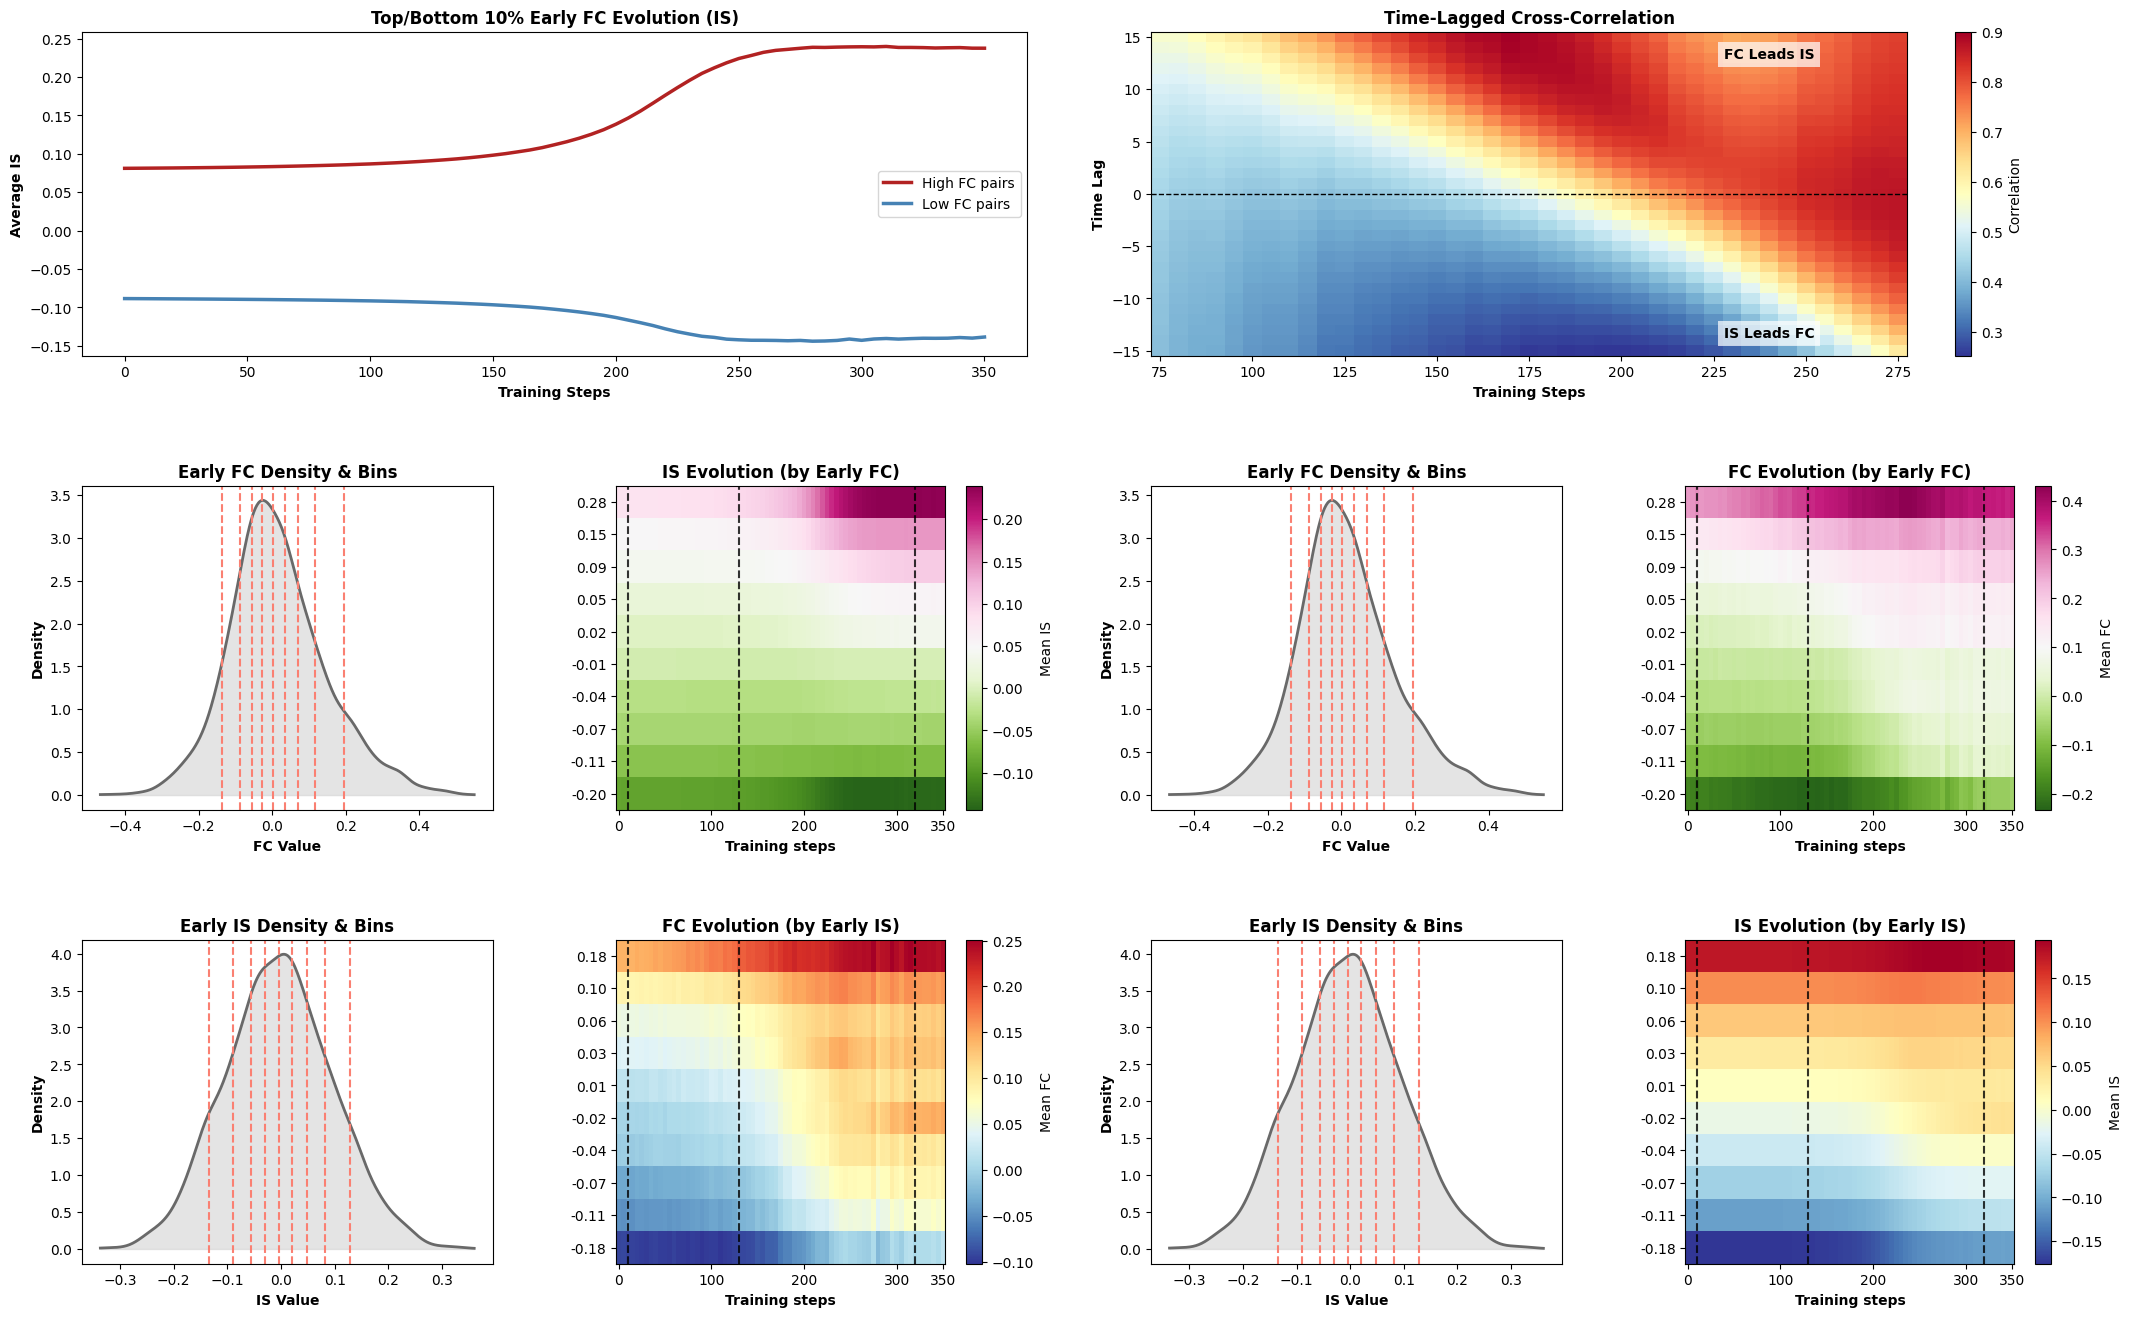

In [7]:
# 1. 运行前三个图表
analyze_macroscopic_dynamics(
    sampled_steps=sampled_steps_full, 
    fc_history=fc_hist_vecs, 
    scc_history=scc_hist_vecs,
    early_step_idx=2,
    window_size=30,
    max_lag=15,
    display_max_steps=350
)

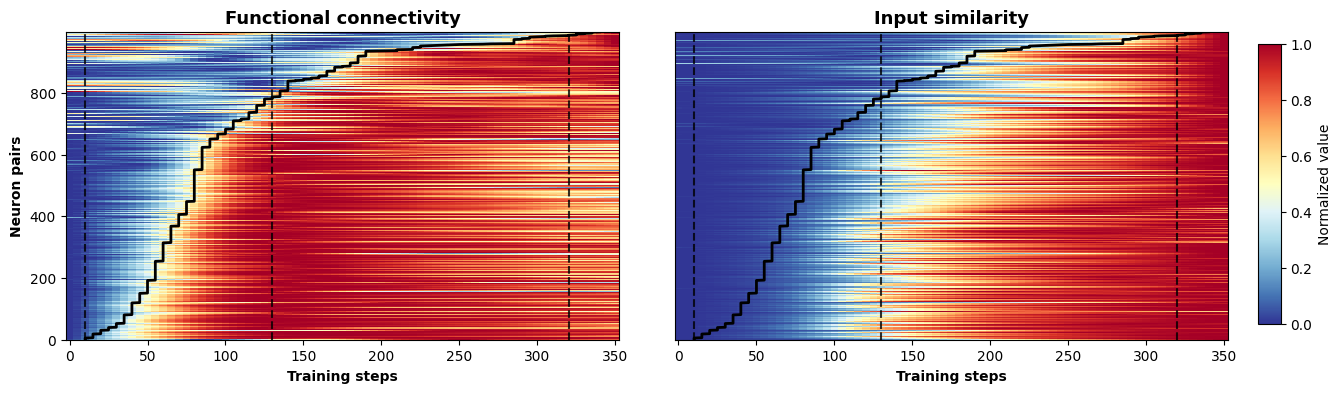

In [5]:
# 2. 运行后两个热图
analyze_gradient_alignment(
    sampled_steps=sampled_steps_full, 
    fc_history=fc_hist_vecs, 
    scc_history=scc_hist_vecs,
    early_step_idx=2,
    display_max_steps=350,
    top_k_pairs=1000
)

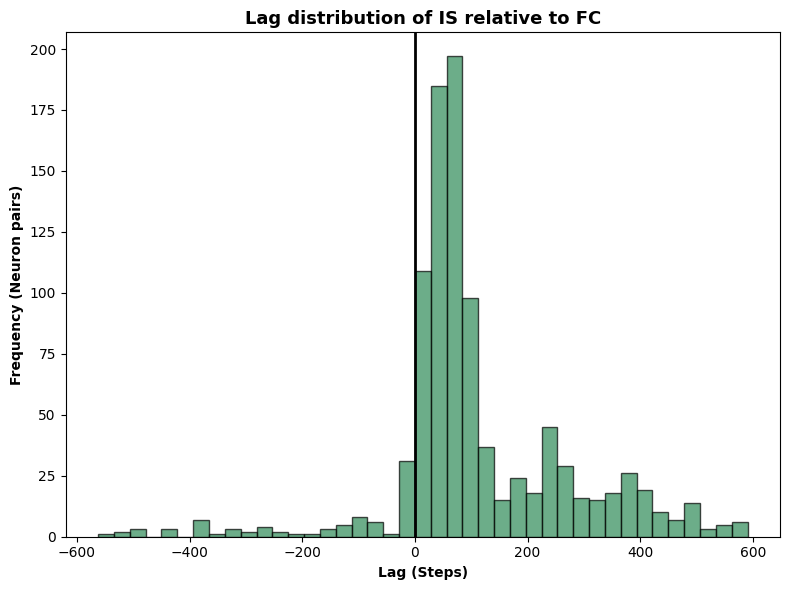

In [7]:
plot_peak_delay_distribution(
    sampled_steps_full, fc_hist_vecs, scc_hist_vecs, 
    top_k_pairs=1000, 
    fc_smooth_sigma=2.0,
    scc_smooth_sigma=2.0
)

### other analysis

In [32]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, optimal_leaf_ordering, dendrogram, leaves_list


def sort_rows_by_similarity(R, method='ward', metric='euclidean'):
    """    
    参数:
    R: 输入矩阵 (n x n 或 n x m)
    method: 聚类方法 ('ward', 'average', 'complete', 'single')
    metric: 距离度量 ('euclidean', 'cosine', 'correlation', 等)
    
    返回:
    R_sorted: 排序后的矩阵
    order: 排序索引
    Z: 层次聚类链接矩阵
    """
    
    # 如果R是方阵且对称，可以直接使用
    # 否则需要计算行之间的距离
    if R.shape[0] == R.shape[1] and np.allclose(R, R.T):
        # 如果是方阵且对称，可以直接使用（如相关系数矩阵）
        # 提取上三角距离
        Y = pdist(R, metric=metric)
    else:
        # 计算行之间的成对距离
        Y = pdist(R, metric=metric)
    
    # 层次聚类
    Z = linkage(Y, method=method)
    
    # 计算最优叶子顺序（需要SciPy >= 1.6.0）
    order = hierarchy.leaves_list(optimal_leaf_ordering(Z, Y))
    
    # # 重新排序矩阵
    # R_sorted = R[order, :][:, order] if R.shape[0] == R.shape[1] else R[order, :]
    
    return order


def plot_fc_scc_heatmap(step=0, save_path=None):
    set_seed(0)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = torchvision.datasets.MNIST(
        root='./data', train=True, transform=transform, download=True
    )
    test_dataset = torchvision.datasets.MNIST(
        root='./data', train=False, transform=transform, download=True
    )
    # batch_size = int(len(train_dataset)/2)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    
    template_model = MLP(input_size=input_size, hidden_dims=hidden_dims)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    template_model.to(device)
    template_model.load_state_dict(models[step])
    # current_model = models[-1]
    FC_train = get_functional_connectivity(template_model, train_loader, samples_per_class=200)
    hid2hid_W = template_model.get_adjacent_weights()[0].cpu().numpy()
    SCC = np.corrcoef(hid2hid_W)

    FC_train = np.nan_to_num(FC_train)

    FC_train = FC_train[100:,100:]

    indices = sort_rows_by_similarity(FC_train)
    data_list = [FC_train[:,indices][indices,:],SCC[:,indices][indices,:]]
    titles = ['Functional connectivity','Input similarity']
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    for i, (data, ax) in enumerate(zip(data_list, axes)):
        sns.heatmap(
            data,
            ax=ax,
            square=True,  # 确保是正方形
            cbar=False,  # 只在最后一个显示colorbar
            cmap='RdBu_r',
            vmin = -1,
            vmax = 1,
            rasterized=True,
        )
        ax.set_title(titles[i], fontsize=12, fontweight='bold')
        ax.axis('off')

    # 调整子图间距
    plt.subplots_adjust(wspace=0.2)
    plt.subplots_adjust(right=0.9)  # 右侧留出15%的空间给colorbar
    fig.suptitle(f'Train Step: {step}', fontsize=14, fontweight='bold')
    # 在右侧添加colorbar
    cbar_ax = fig.add_axes([0.92, 0.35, 0.01, 0.4])  # [left, bottom, width, height]
    fig.colorbar(axes[0].collections[0], cax=cbar_ax)

    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=600)
    
    plt.show()
    return FC_train, SCC

import matplotlib.pyplot as plt
import seaborn as sns

def plot_matrix_density(matrix1, matrix2, label1='Functional connectivity', label2='Input similarity', save_path=None):
    """
    绘制两个矩阵值的分布密度曲线。
    
    参数:
        matrix1: 第一个矩阵 (list, numpy array 或 tensor 等)
        matrix2: 第二个矩阵 (list, numpy array 或 tensor 等)
        label1: 第一个矩阵在图例中的名称
        label2: 第二个矩阵在图例中的名称
        save_path: 图片保存路径，若提供则保存文件
    """
    # 将输入统一转换为 numpy array 并展平为一维
    # 这一步是必须的，否则核密度估计无法处理多维结构
    np.fill_diagonal(matrix1, 0)
    np.fill_diagonal(matrix2, 0)
    flat_m1 = np.asarray(matrix1).flatten()
    flat_m2 = np.asarray(matrix2).flatten()
    
    # 初始化画布并设置基础网格样式
    plt.figure(figsize=(6, 5))
    
    # 绘制第一条密度曲线
    # fill=True 表示在曲线下方填充颜色，alpha 设置透明度避免相互遮挡
    sns.kdeplot(flat_m1, fill=True, color='tab:blue', alpha=0.4, label=label1, linewidth=1)
    
    # 绘制第二条密度曲线
    sns.kdeplot(flat_m2, fill=True, color='tab:orange', alpha=0.4, label=label2, linewidth=1)
    
    # 设置图表元素
    plt.title('Density Distribution of Matrix Values', fontsize=14, pad=15)
    plt.xlabel('Value', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(loc='best', fontsize=8)
    
    # 设置边框粗细 (与你之前的图表风格保持一致)
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(0.25)
        spine.set_alpha(0.4)
    
    plt.tight_layout()
    plt.xlim(-1, 1)  # 根据你的数据范围调整
    
    # 保存或展示图表
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=600)
        
    plt.show()


def plot_fc_scc_scatter(FC_train, FC_test, FC_noise, SCC):
    """
    绘制功能连接性与结构连接性之间的散点图
    """
    # 提取上三角部分
    triu_indices = np.triu_indices_from(SCC, k=1)
    scc_values = SCC[triu_indices]
    fc_train_values = FC_train[triu_indices]
    fc_test_values = FC_test[triu_indices]
    fc_noise_values = FC_noise[triu_indices]

    # 创建子图
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 绘制散点图
    axes[0].scatter(scc_values, fc_train_values, alpha=0.5, s=15)
    axes[0].set_title('pearson r={:.2f}'.format(np.corrcoef(scc_values, fc_train_values)[0,1]), fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Input similarity', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Functional connectivity', fontsize=12, fontweight='bold')

    axes[1].scatter(scc_values, fc_test_values, alpha=0.5, color='green')
    axes[1].set_title('FC (Test Data) vs input similarity\npearson r={:.2f}'.format(np.corrcoef(scc_values, fc_test_values)[0,1]))
    axes[1].set_xlabel('input similarity')
    axes[1].set_ylabel('FC (Test Data)')

    axes[2].scatter(scc_values, fc_noise_values, alpha=0.5, color='red')
    axes[2].set_title('FC (Noise) vs input similarity\npearson r={:.2f}'.format(np.corrcoef(scc_values, fc_noise_values)[0,1]))
    axes[2].set_xlabel('input similarity')
    axes[2].set_ylabel('FC (Noise)')

    plt.tight_layout()
    plt.show()

from scipy import stats

def plot_fc_is_scatter(FC_train, IS, save_path=None):
    triu_indices = np.triu_indices_from(IS, k=1)
    scc_values = IS[triu_indices]
    fc_train_values = FC_train[triu_indices]


    fig, ax = plt.subplots(figsize=(7, 6), dpi=120)

    # 计算统计量
    pearson_corr, p_value = stats.pearsonr(scc_values, fc_train_values)
    m, b = np.polyfit(scc_values, fc_train_values, 1)

    # 绘制散点：减小点大小(s=15)，调整颜色为现代感强的十六进制色
    ax.scatter(scc_values, fc_train_values, alpha=0.5, s=15, color='#4169E1', edgecolors='none', rasterized=True)

    # 绘制回归线：使用更鲜明的对比色
    ax.plot(scc_values, m * scc_values + b, color="#000000", linewidth=0.5, 
            label=f'r={pearson_corr:.3f}')

    # 坐标轴和标题美化，加粗字体
    ax.set_xlabel('Input Similarity  (IS)', fontsize=18)
    ax.set_ylabel('Functional Connectivity (FC)', fontsize=18)
    ax.set_title(f'r={pearson_corr:.3f}', fontsize=14, fontweight='bold', pad=15)

    # 将 x 轴和 y 轴的刻度标签加粗
    plt.setp(ax.get_xticklabels())
    plt.setp(ax.get_yticklabels())

    border_width = 0.25      # 边框粗细
    border_alpha = 0.4      # 边框透明度 (0到1之间)
    tick_width = 0.25        # 刻度线粗细
    tick_alpha = 0.4        # 刻度线透明度 (通过 RGBA 颜色实现)

    for spine in ax.spines.values():
        spine.set_linewidth(border_width)
        spine.set_alpha(border_alpha)
        
    # 2. 调节刻度线 (ticks) 的粗细、长度和透明度
    # 注意：tick_params 中没有直接的 alpha 参数，需要通过传入带 alpha 通道的 RGBA 颜色来实现透明度
    # (0, 0, 0, tick_alpha) 代表黑色，带有指定的透明度
    ax.tick_params(axis='both', 
                    which='major', 
                    width=tick_width, 
                    color=(0, 0, 0, tick_alpha))

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#333333')
    ax.spines['left'].set_color('#333333')

    # ax.set(xlim=(-1, 1), ylim=(-1, 1))
    # ax.set_aspect('equal')
    ax.set_aspect('equal', adjustable='box')

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    lower = min(xlim[0], ylim[0])
    upper = max(xlim[1], ylim[1])

    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)

    # 优化图例：添加阴影，放置在最佳位置
    # ax.legend(frameon=False, shadow=False, prop={'weight': 'bold', 'size': 16}, loc='best')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format='pdf')
    plt.show()


In [76]:
len(models)

1175

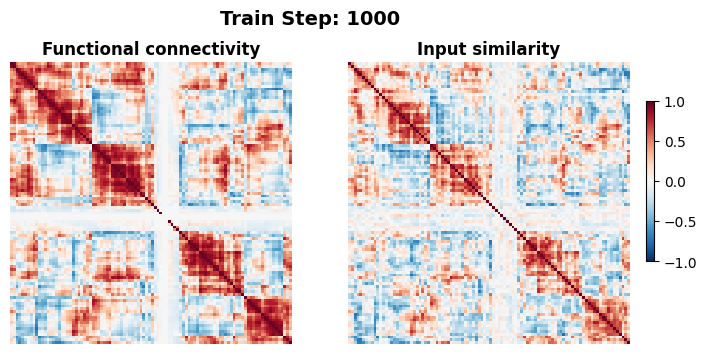

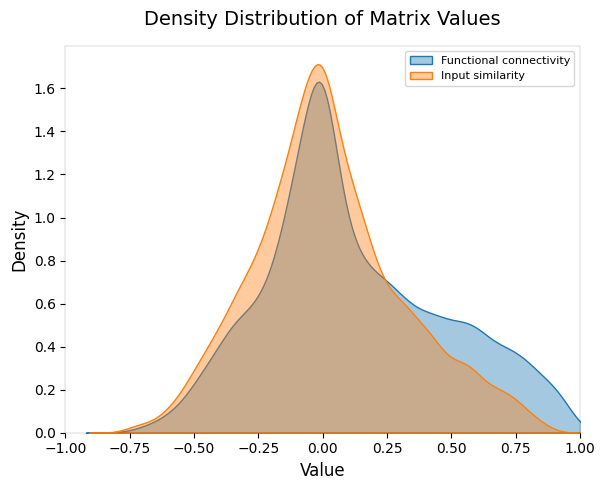

  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: float or None
  animated: bool
  antialiased: bool
  backgroundcolor: :mpltype:`color`
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  fontfamily or family or fontname: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 

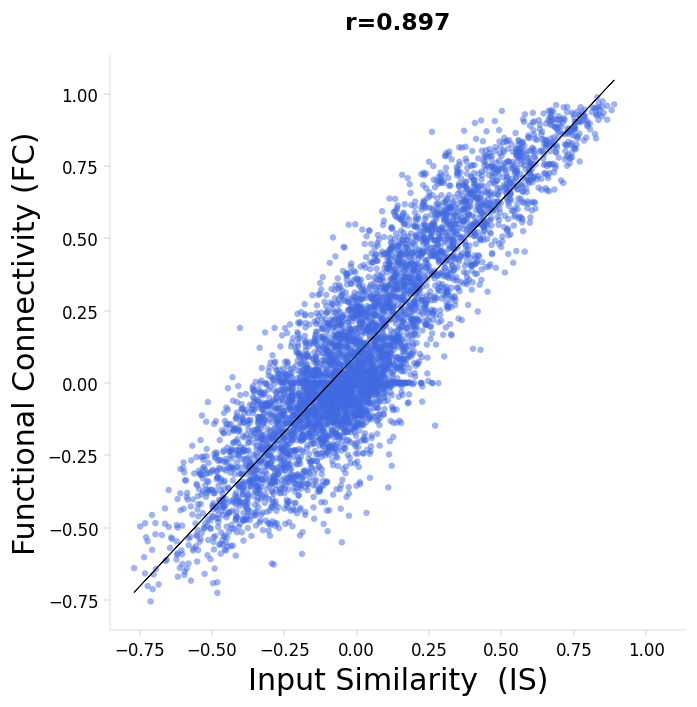

In [36]:
step = 1000
FC_train, IS = plot_fc_scc_heatmap(step=step, 
                                   save_path=f'./fig/fc_is_heatmap_step{step}.pdf'
                                   )
plot_matrix_density(FC_train, IS, 
                    save_path=f'./fig/fc_is_density_step{step}.pdf'
                    )
plot_fc_is_scatter(FC_train, IS, 
                   save_path=f'./fig/fc_is_scatter_step{step}.pdf'
                   )